# Public Opinion on Single Parenthood in DACH Reddit Communities (2015–2025)

**Proof-of-Concept Research Tool**

This notebook analyses public discourse about *Alleinerziehende* (single parents) across German-speaking Reddit communities in the DACH region (Germany, Austria, Switzerland). It collects posts from 2015–2025, applies multilingual sentiment analysis, and produces statistical summaries and visualisations suitable for social-science research.

**Key design choices:**
- **No paid APIs** — uses only free, open-source tools
- **No Reddit credentials** — data comes from the Arctic Shift public archive
- **Offline-capable** — after the first run (which downloads one ~1 GB model), everything runs locally
- **Caching** — raw data and sentiment results are cached to JSON so you never re-fetch unnecessarily

## Cell 1 — Install Dependencies

In [22]:
# Cell 1 — Install all required packages (runs once; safe to re-run)
# This cell installs everything needed. On Google Colab, all installs
# happen in your temporary runtime and won't affect your system.

!pip install -q \
    requests \
    pandas \
    matplotlib \
    seaborn \
    "vaderSentiment" \
    "transformers>=4.36.0" \
    "torch>=2.0" \
    "safetensors>=0.4" \
    "protobuf>=3.20" \
    "scikit-learn>=1.0" \
    langdetect \
    scipy \
    nltk

# Topic modeling — BERTopic with KeyBERT-based labeling
!pip install -q \
    "bertopic>=0.16" \
    "sentence-transformers>=2.2" \
    "umap-learn>=0.5" \
    "hdbscan>=0.8" \
    "keybert"

print("All packages installed successfully.")

All packages installed successfully.


## Cell 2 — Import Libraries

In [23]:
# Cell 2 — Import all libraries used throughout the notebook

import os
import json
import time
import re
import html
import warnings
from datetime import datetime, timezone
from collections import Counter, defaultdict

import requests
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    pipeline,
)
from langdetect import detect, LangDetectException
import nltk

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

# Download NLTK stopwords for text statistics
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

# Suppress noisy warnings that don't affect results
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Plotting defaults
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

print("All imports ready.")

All imports ready.


## Cell 3 — Configuration

Edit the lists below if you want to adjust the scope of the analysis  
(e.g., add subreddits, change the time window, or add keywords).

In [24]:
# Cell 3 — Central configuration — edit here to customise the analysis

# Subreddits to search (DACH-focused, expanded)
SUBREDDITS = [
    "Austria", "de", "Switzerland", "wien", "DACH",
    "germany", "Oesterreich", "Schweiz", "berlin", "hamburg",
    "Munich", "cologne", "Frankfurt", "Stuttgart", "Düsseldorf",
    "AskEurope", "europe", "beziehungen", "eltern", "fragreddit", 
    "fragtmaenner", "fragnefrau", "finanzen", "ratschlag"
]

# German keywords
KEYWORDS_DE = [
    "Alleinerziehende",
    "Alleinerziehender",
    "Einelternfamilie",
    "alleinerziehend",
    "Alleinerziehenden",
    "Alleinerzieherin",
    "Sozialmutter",
    "Solovater",
    "Solomutter",
]

# English keywords
KEYWORDS_EN = [
    "single parent",
    "single mother",
    "single father",
    "single mom",
    "single dad",
    "lone parent",
]

KEYWORDS = KEYWORDS_DE + KEYWORDS_EN

# Year range (inclusive)
YEAR_START = 2015
YEAR_END = 2025
YEARS = list(range(YEAR_START, YEAR_END + 1))

# API settings
ARCTIC_SHIFT_URL          = "https://arctic-shift.photon-reddit.com/api/posts/search"
ARCTIC_SHIFT_COMMENTS_URL = "https://arctic-shift.photon-reddit.com/api/comments/search"
PULLPUSH_URL              = "https://api.pullpush.io/reddit/search/submission/"
PULLPUSH_COMMENTS_URL     = "https://api.pullpush.io/reddit/search/comment/"
REQUEST_DELAY     = 0.3   # seconds between API calls
PAGE_LIMIT        = 100   # posts per page (Arctic Shift max is 100)
MAX_PAGES         = 20    # safety cap per combo (= up to 2 000 posts per combo)
MAX_COMMENTS_PER_POST = 500  # max comments to fetch per post

# Cache file paths
RAW_CACHE_FILE       = "../data/reddit/raw_posts_cache.json"
COMMENTS_CACHE_FILE  = "../data/reddit/raw_comments_cache.json"
SENTIMENT_CACHE_FILE = "../data/reddit/sentiment_cache.json"

# RoBERTa batch size (lower if you run out of memory)
ROBERTA_BATCH_SIZE = 16

# ── Topic analysis settings ───────────────────────────────────────────────────
# Multilingual sentence-transformer (~400 MB, downloaded once).
EMBEDDING_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"

# Number of final topics after hierarchical reduction.
# BERTopic first discovers many micro-clusters, then merges them down
# to this number. 10–15 works well for ~6k posts.
N_TOPICS = 12

# Minimum posts per initial cluster. Higher = fewer, cleaner topics.
# (The old value of 5 produced 117 garbage topics.)
MIN_TOPIC_SIZE = 20

# Minimum text length (characters) for topic modeling.
# Very short posts are noise to the sentence embedder.
MIN_TEXT_LEN_FOR_TOPICS = 50

# Cache for topic results
TOPIC_CACHE_FILE = "../data/reddit/topic_cache.json" 
# ── Relevance filtering ──────────────────────────────────────────────────────
# After collection, posts are hard-filtered against these keywords.
# German keywords use SUBSTRING matching (to catch compound words like
# "Alleinerziehendenhilfe"). English keywords use WORD-BOUNDARY matching
# with support for plurals (mothers/fathers) and hyphens (single-parent).

RELEVANCE_KEYWORDS_DE = [
    "alleinerziehende", "alleinerziehender", "alleinerziehenden",
    "alleinerziehend", "einelternfamilie", "einelternhaushalt",
    "allein erziehend",
    "sorgerecht", "kindesunterhalt", "unterhaltspflicht",
    "unterhaltsvorschuss",
]

RELEVANCE_KEYWORDS_EN = [
    "single parent", "single mother", "single father",
    "single parenting", "single mom", "single dad",
    "solo parent", "lone parent",
]

def build_query(keyword):
    """Wrap multi-word keywords in quotes for exact phrase matching at API level."""
    if " " in keyword.strip():
        return f'"{keyword}"'
    return keyword

print("✅ Configuration loaded.")
print(f"   {len(SUBREDDITS)} subreddits × {len(KEYWORDS)} keywords × {len(YEARS)} years")
print(f"   = up to {len(SUBREDDITS) * len(KEYWORDS) * len(YEARS)} query-combos")
print(f"   = up to {len(SUBREDDITS) * len(KEYWORDS) * len(YEARS) * PAGE_LIMIT * MAX_PAGES:,} posts (with pagination)")


✅ Configuration loaded.
   24 subreddits × 15 keywords × 9 years
   = up to 3240 query-combos
   = up to 6,480,000 posts (with pagination)


## Cell 4 — Data Collection

This cell fetches posts from the **Arctic Shift** public Reddit archive  
(with PullPush as a fallback). Results are cached to `raw_posts_cache.json`  
so you only need internet access the first time.

In [25]:
# Cell 4 — Fetch Reddit posts via Arctic Shift / PullPush (with caching + pagination)

def fetch_page_arctic_shift(keyword, subreddit, after_ts, before_ts):
    """
    Fetch one page from Arctic Shift.
    Returns (posts_list, last_result_ts) where last_result_ts is the
    oldest timestamp in the page (used as the next `before` cursor).
    """
    q = build_query(keyword)
    params = {
        "query":     q,             # multi-word keywords are quoted
        "subreddit": subreddit,
        "after":     int(after_ts),
        "before":    int(before_ts),
        "limit":     PAGE_LIMIT,
        "sort":      "desc",
    }
    try:
        resp = requests.get(ARCTIC_SHIFT_URL, params=params, timeout=30)
        if resp.status_code == 200:
            body  = resp.json()
            posts = body.get("data") or []
            # Arctic Shift returns meta.last_result as the oldest timestamp
            last_ts = (body.get("meta") or {}).get("last_result")
            return posts, last_ts
    except Exception:
        pass
    return [], None


def fetch_page_pullpush(keyword, subreddit, after_ts, before_ts):
    """PullPush fallback — used only when Arctic Shift fails completely."""
    try:
        q = build_query(keyword)
        params = {
            "q":         q,
            "subreddit": subreddit,
            "after":     int(after_ts),
            "before":    int(before_ts),
            "size":      PAGE_LIMIT,
            "sort":      "desc",
        }
        resp = requests.get(PULLPUSH_URL, params=params, timeout=30)
        if resp.status_code == 200:
            data  = resp.json()
            posts = data.get("data") or []
            if posts:
                last_ts = min(int(p.get("created_utc", before_ts)) for p in posts)
                return posts, last_ts
    except Exception:
        pass
    return [], None


def fetch_all_pages(keyword, subreddit, after_ts, before_ts):
    """
    Paginate through ALL posts for one (keyword, subreddit, year) combo.

    Uses Arctic Shift's meta.last_result as the cursor: each response
    contains the oldest timestamp in that page, which becomes the next
    `before` so we walk backwards through the year.
    Falls back to PullPush only if Arctic Shift returns nothing at all
    on the very first page.
    """
    collected = []
    seen_ids  = set()
    current_before = int(before_ts)
    used_pullpush  = False

    for _page in range(MAX_PAGES):
        posts, last_ts = fetch_page_arctic_shift(
            keyword, subreddit, int(after_ts), current_before
        )
        time.sleep(REQUEST_DELAY)

        # If Arctic Shift gave nothing on page 1, try PullPush once
        if not posts and _page == 0 and not used_pullpush:
            posts, last_ts = fetch_page_pullpush(
                keyword, subreddit, int(after_ts), current_before
            )
            used_pullpush = True
            time.sleep(REQUEST_DELAY)

        if not posts:
            break

        new_posts = [p for p in posts if p.get("id") not in seen_ids]
        if not new_posts:
            break

        for p in new_posts:
            seen_ids.add(p.get("id"))
        collected.extend(new_posts)

        # Stop if we got a partial page — no more results
        if len(posts) < PAGE_LIMIT:
            break

        # Advance cursor using Arctic Shift's meta cursor, or manual fallback
        if last_ts is not None:
            next_before = int(last_ts) - 1
        else:
            next_before = min(int(p.get("created_utc", current_before)) for p in new_posts) - 1

        if next_before <= int(after_ts):
            break
        current_before = next_before

    return collected


def collect_all_posts():
    """Loop over every year × keyword × subreddit combination with pagination."""
    all_posts = []
    seen_ids  = set()
    total_combos = len(YEARS) * len(KEYWORDS) * len(SUBREDDITS)
    done = 0

    for year in YEARS:
        after_ts  = int(datetime(year,  1,  1,  0,  0,  0, tzinfo=timezone.utc).timestamp())
        before_ts = int(datetime(year, 12, 31, 23, 59, 59, tzinfo=timezone.utc).timestamp())

        for keyword in KEYWORDS:
            for subreddit in SUBREDDITS:
                done += 1
                if done % 50 == 0 or done == total_combos:
                    print(f"  [{done}/{total_combos}] {year} | r/{subreddit} | '{keyword}' "
                          f"| total so far: {len(all_posts):,}")

                posts = fetch_all_pages(keyword, subreddit, after_ts, before_ts)

                for p in posts:
                    pid = p.get("id")
                    if pid and pid in seen_ids:
                        continue   # global dedup across overlapping keyword/subreddit combos
                    seen_ids.add(pid)
                    p["_query_keyword"]   = keyword
                    p["_query_subreddit"] = subreddit
                    p["_query_year"]      = year
                    all_posts.append(p)

    return all_posts


# ── Check cache ──
if os.path.exists(RAW_CACHE_FILE):
    print(f"📦 Cache found ({RAW_CACHE_FILE}). Loading from disk …")
    print(f"   ⚠️  To re-fetch with updated keywords/settings, delete this file first.")
    with open(RAW_CACHE_FILE, "r", encoding="utf-8") as f:
        raw_posts = json.load(f)
    print(f"   Loaded {len(raw_posts):,} raw records from cache.")
else:
    print("🌐 No cache found. Fetching via Arctic Shift (with pagination) …")
    raw_posts = collect_all_posts()
    with open(RAW_CACHE_FILE, "w", encoding="utf-8") as f:
        json.dump(raw_posts, f, ensure_ascii=False)
    print(f"\n✅ Fetched and cached {len(raw_posts):,} raw records.")

RAW_TOTAL = len(raw_posts)
print(f"\nTotal raw records: {RAW_TOTAL:,}")


# ── Comment Collection ──────────────────────────────────────────────────────

def fetch_comments_page_arctic(post_id, before_ts):
    """
    Fetch one page of comments for a post from Arctic Shift.
    Uses link_id=t3_{post_id} to scope results to the thread.
    Returns (comments_list, last_result_ts).
    """
    params = {
        "link_id": f"t3_{post_id}",
        "before":  int(before_ts),
        "limit":   PAGE_LIMIT,
        "sort":    "desc",
    }
    try:
        resp = requests.get(ARCTIC_SHIFT_COMMENTS_URL, params=params, timeout=30)
        if resp.status_code == 200:
            body     = resp.json()
            comments = body.get("data") or []
            last_ts  = (body.get("meta") or {}).get("last_result")
            return comments, last_ts
    except Exception:
        pass
    return [], None


def fetch_comments_page_pullpush(post_id, before_ts):
    """PullPush fallback for comments."""
    try:
        params = {
            "link_id": f"t3_{post_id}",
            "before":  int(before_ts),
            "size":    PAGE_LIMIT,
            "sort":    "desc",
        }
        resp = requests.get(PULLPUSH_COMMENTS_URL, params=params, timeout=30)
        if resp.status_code == 200:
            data     = resp.json()
            comments = data.get("data") or []
            if comments:
                last_ts = min(int(c.get("created_utc", before_ts)) for c in comments)
                return comments, last_ts
    except Exception:
        pass
    return [], None


def fetch_comments_for_post(post):
    """
    Fetch all comments for a single post (paginated).
    Inherits metadata from the parent post.
    """
    post_id      = post.get("id")
    created_utc  = int(post.get("created_utc", 0))
    # Comments can only exist after the post; use a generous future bound
    import time as _time
    before_ts    = int(_time.time()) + 1

    collected  = []
    seen_ids   = set()
    used_pp    = False

    for _page in range(MAX_PAGES):
        if len(collected) >= MAX_COMMENTS_PER_POST:
            break

        comments, last_ts = fetch_comments_page_arctic(post_id, before_ts)
        time.sleep(REQUEST_DELAY)

        if not comments and _page == 0 and not used_pp:
            comments, last_ts = fetch_comments_page_pullpush(post_id, before_ts)
            used_pp = True
            time.sleep(REQUEST_DELAY)

        if not comments:
            break

        new_comments = [c for c in comments if c.get("id") not in seen_ids]
        if not new_comments:
            break

        for c in new_comments:
            seen_ids.add(c.get("id"))
            c["_post_id"]          = post_id
            c["_query_keyword"]    = post.get("_query_keyword", "")
            c["_query_subreddit"]  = post.get("_query_subreddit", "")
            c["_query_year"]       = post.get("_query_year", "")
        collected.extend(new_comments)

        if len(comments) < PAGE_LIMIT:
            break

        if last_ts is not None:
            next_before = int(last_ts) - 1
        else:
            next_before = min(int(c.get("created_utc", before_ts)) for c in new_comments) - 1

        if next_before <= created_utc:
            break
        before_ts = next_before

    return collected


def collect_all_comments(posts):
    """Fetch comments for every collected post."""
    all_comments = []
    seen_ids     = set()
    total        = len(posts)

    for idx, post in enumerate(posts):
        if (idx + 1) % 50 == 0 or (idx + 1) == total:
            print(f"  [comments {idx+1}/{total}] collected so far: {len(all_comments):,}")

        comments = fetch_comments_for_post(post)
        for c in comments:
            cid = c.get("id")
            if cid in seen_ids:
                continue
            seen_ids.add(cid)
            all_comments.append(c)

    return all_comments


# ── Load or fetch comments (cached) ─────────────────────────────────────────

if os.path.exists(COMMENTS_CACHE_FILE):
    print(f"\n📦 Comments cache found ({COMMENTS_CACHE_FILE}). Loading …")
    with open(COMMENTS_CACHE_FILE, "r", encoding="utf-8") as f:
        raw_comments = json.load(f)
    print(f"   Loaded {len(raw_comments):,} raw comments from cache.")
else:
    print(f"\n🌐 Fetching comments for {len(raw_posts):,} posts …")
    raw_comments = collect_all_comments(raw_posts)
    with open(COMMENTS_CACHE_FILE, "w", encoding="utf-8") as f:
        json.dump(raw_comments, f, ensure_ascii=False)
    print(f"\n✅ Fetched and cached {len(raw_comments):,} comments.")

RAW_COMMENTS_TOTAL = len(raw_comments)
print(f"Total raw records: {RAW_TOTAL:,} posts + {RAW_COMMENTS_TOTAL:,} comments "
      f"= {RAW_TOTAL + RAW_COMMENTS_TOTAL:,} total")


🌐 No cache found. Fetching via Arctic Shift (with pagination) …
  [50/3240] 2015 | r/de | 'Einelternfamilie' | total so far: 2
  [100/3240] 2015 | r/wien | 'Alleinerziehenden' | total so far: 2
  [150/3240] 2015 | r/germany | 'Sozialmutter' | total so far: 2
  [200/3240] 2015 | r/Schweiz | 'Solomutter' | total so far: 2
  [250/3240] 2015 | r/hamburg | 'single mother' | total so far: 4
  [300/3240] 2015 | r/cologne | 'single mom' | total so far: 12
  [350/3240] 2015 | r/Stuttgart | 'lone parent' | total so far: 13
  [400/3240] 2016 | r/AskEurope | 'Alleinerziehender' | total so far: 21
  [450/3240] 2016 | r/beziehungen | 'alleinerziehend' | total so far: 22
  [500/3240] 2016 | r/fragreddit | 'Alleinerzieherin' | total so far: 23
  [550/3240] 2016 | r/fragnefrau | 'Solovater' | total so far: 23
  [600/3240] 2016 | r/ratschlag | 'single parent' | total so far: 23
  [650/3240] 2016 | r/de | 'single mom' | total so far: 29
  [700/3240] 2016 | r/wien | 'lone parent' | total so far: 31
  [750

In [30]:
# Run ONCE to add 2024-2025, then delete or skip this cell
'''
import json

NEW_YEARS = [2024, 2025]

with open(RAW_CACHE_FILE, "r", encoding="utf-8") as f:
    existing = json.load(f)
existing_ids = {p["id"] for p in existing}
print(f"Existing cache: {len(existing):,} posts")

new_posts = []
total_combos = len(NEW_YEARS) * len(KEYWORDS) * len(SUBREDDITS)
done = 0

for year in NEW_YEARS:
    after_ts = int(datetime(year, 1, 1, tzinfo=timezone.utc).timestamp())
    before_ts = int(datetime(year, 12, 31, 23, 59, 59, tzinfo=timezone.utc).timestamp())
    for keyword in KEYWORDS:
        for subreddit in SUBREDDITS:
            done += 1
            if done % 50 == 0 or done == total_combos:
                print(f"  [{done}/{total_combos}] {year} | r/{subreddit} | '{keyword}'")
            posts = fetch_all_pages(keyword, subreddit, after_ts, before_ts)
            for p in posts:
                if p.get("id") not in existing_ids:
                    p["_query_keyword"] = keyword
                    p["_query_subreddit"] = subreddit
                    p["_query_year"] = year
                    new_posts.append(p)
                    existing_ids.add(p["id"])

print(f"\nNew posts fetched: {len(new_posts):,}")
existing.extend(new_posts)
with open(RAW_CACHE_FILE, "w", encoding="utf-8") as f:
    json.dump(existing, f, ensure_ascii=False)
raw_posts = existing
RAW_TOTAL = len(raw_posts)
print(f"Updated cache: {RAW_TOTAL:,} total posts")
'''

Existing cache: 441 posts
  [50/720] 2024 | r/de | 'Einelternfamilie'
  [100/720] 2024 | r/wien | 'Alleinerziehenden'
  [150/720] 2024 | r/germany | 'Sozialmutter'
  [200/720] 2024 | r/Schweiz | 'Solomutter'
  [250/720] 2024 | r/hamburg | 'single mother'
  [300/720] 2024 | r/cologne | 'single mom'
  [350/720] 2024 | r/Stuttgart | 'lone parent'
  [400/720] 2025 | r/AskEurope | 'Alleinerziehender'
  [450/720] 2025 | r/beziehungen | 'alleinerziehend'
  [500/720] 2025 | r/fragreddit | 'Alleinerzieherin'
  [550/720] 2025 | r/fragnefrau | 'Solovater'
  [600/720] 2025 | r/ratschlag | 'single parent'
  [650/720] 2025 | r/de | 'single mom'
  [700/720] 2025 | r/wien | 'lone parent'
  [720/720] 2025 | r/ratschlag | 'lone parent'

New posts fetched: 838
Updated cache: 1,279 total posts


In [31]:
'''
# Fetch comments for NEW posts only, merge into existing cache

with open(COMMENTS_CACHE_FILE, "r", encoding="utf-8") as f:
    existing_comments = json.load(f)
existing_comment_ids = {c["id"] for c in existing_comments}

# Find posts that don't have comments fetched yet
posts_with_comments = {c.get("_post_id") for c in existing_comments}
new_post_objs = [p for p in raw_posts if p["id"] not in posts_with_comments]
print(f"Fetching comments for {len(new_post_objs):,} new posts...")

for idx, post in enumerate(new_post_objs):
    if (idx + 1) % 20 == 0:
        print(f"  [{idx+1}/{len(new_post_objs)}]")
    comments = fetch_comments_for_post(post)
    for c in comments:
        if c["id"] not in existing_comment_ids:
            existing_comments.append(c)
            existing_comment_ids.add(c["id"])

with open(COMMENTS_CACHE_FILE, "w", encoding="utf-8") as f:
    json.dump(existing_comments, f, ensure_ascii=False)
raw_comments = existing_comments
RAW_COMMENTS_TOTAL = len(raw_comments)
print(f"Updated comments cache: {RAW_COMMENTS_TOTAL:,}")
'''

Fetching comments for 873 new posts...
  [20/873]
  [40/873]
  [60/873]
  [80/873]
  [100/873]
  [120/873]
  [140/873]
  [160/873]
  [180/873]
  [200/873]
  [220/873]
  [240/873]
  [260/873]
  [280/873]
  [300/873]
  [320/873]
  [340/873]
  [360/873]
  [380/873]
  [400/873]
  [420/873]
  [440/873]
  [460/873]
  [480/873]
  [500/873]
  [520/873]
  [540/873]
  [560/873]
  [580/873]
  [600/873]
  [620/873]
  [640/873]
  [660/873]
  [680/873]
  [700/873]
  [720/873]
  [740/873]
  [760/873]
  [780/873]
  [800/873]
  [820/873]
  [840/873]
  [860/873]
Updated comments cache: 61,465


## Cell 5 — Preprocessing

Clean up the raw data: merge title + body, remove noise, deduplicate,  
detect language, and keep only German / English posts with enough text.

In [32]:
# Cell 5 — Preprocessing pipeline

def clean_text(text):
    """Remove URLs, Reddit references, HTML entities, and excess whitespace."""
    text = html.unescape(text)
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"/u/\S+", "", text)
    text = re.sub(r"/r/\S+", "", text)
    text = re.sub(r"&\w+;", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def detect_lang(text):
    """Return ISO-639-1 language code or 'unknown'."""
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"


# ── Build posts DataFrame ────────────────────────────────────────────────────
df_raw = pd.DataFrame(raw_posts)

for col in ["title", "selftext", "id", "subreddit", "score",
            "num_comments", "created_utc", "author",
            "_query_keyword", "_query_year"]:
    if col not in df_raw.columns:
        df_raw[col] = "" if col in ["title", "selftext", "author"] else 0

df_raw["title"]    = df_raw["title"].fillna("").astype(str)
df_raw["selftext"] = df_raw["selftext"].fillna("").astype(str)
df_raw["full_text"] = (df_raw["title"] + " " + df_raw["selftext"]).apply(clean_text)
df_raw["type"]     = "post"
df_raw["parent_post_id"] = ""

# ── Build comments DataFrame ─────────────────────────────────────────────────
df_comments_raw = pd.DataFrame(raw_comments) if raw_comments else pd.DataFrame()

if len(df_comments_raw) > 0:
    for col in ["body", "id", "subreddit", "score", "created_utc", "author",
                "_query_keyword", "_query_year", "_post_id", "link_id"]:
        if col not in df_comments_raw.columns:
            df_comments_raw[col] = "" if col in ["body", "author", "_post_id", "link_id"] else 0

    df_comments_raw["body"]      = df_comments_raw["body"].fillna("").astype(str)
    df_comments_raw["full_text"] = df_comments_raw["body"].apply(clean_text)
    df_comments_raw["title"]     = ""
    df_comments_raw["selftext"]  = ""
    df_comments_raw["num_comments"] = 0
    df_comments_raw["type"]      = "comment"
    # Extract parent post id from link_id (format: "t3_POSTID")
    df_comments_raw["parent_post_id"] = df_comments_raw["link_id"].astype(str).str.replace(r"^t3_", "", regex=True)

# ── Combine ──────────────────────────────────────────────────────────────────
df_combined = pd.concat(
    [df_raw, df_comments_raw] if len(df_comments_raw) > 0 else [df_raw],
    ignore_index=True, sort=False
)

# Drop deleted / removed / too-short entries
drop_patterns = {"[deleted]", "[removed]", ""}
df_combined = df_combined[~df_combined["full_text"].str.strip().isin(drop_patterns)]
df_combined = df_combined[df_combined["full_text"].str.len() >= 20]

BEFORE_DEDUP = len(df_combined)

# Deduplicate on id
df_combined = df_combined.drop_duplicates(subset="id", keep="first")
AFTER_DEDUP = len(df_combined)


# ── Relevance filter (POSTS only) ────────────────────────────────────────────
# German: substring match catches compound words (Alleinerziehendenhilfe)
# English: word-boundary regex with optional plural/hyphen support
#          prevents "a single year" from matching "single parent"

def matches_any_keyword(text, de_keywords, en_keywords):
    """Check if text contains at least one relevant keyword."""
    text_lower = text.lower()
    # German: substring match (handles compounds)
    for kw in de_keywords:
        if kw in text_lower:
            return True
    # English: word-boundary + optional plural 's'/'ing' + hyphen support
    for kw in en_keywords:
        pat = r'\b' + re.escape(kw).replace(r'\ ', r'[\s\-]') + r'(?:s|ing)?\b'
        if re.search(pat, text_lower):
            return True
    return False

# Apply keyword filter to POSTS only — comments are part of a relevant
# discussion by definition, regardless of their own wording.
is_post = df_combined["type"] == "post"
posts_before = int(is_post.sum())

post_mask = is_post & df_combined["full_text"].apply(
    lambda t: matches_any_keyword(t, RELEVANCE_KEYWORDS_DE, RELEVANCE_KEYWORDS_EN)
)
comment_mask = ~is_post  # keep all comments for now
df_combined = df_combined[post_mask | comment_mask].copy()

posts_after = int((df_combined["type"] == "post").sum())
print(f"🔍 Relevance filter (posts only): {posts_before:,} → {posts_after:,} "
      f"({posts_before - posts_after:,} irrelevant posts removed)")

# Drop orphaned comments whose parent post was filtered out
if (df_combined["type"] == "comment").any():
    valid_post_ids = set(df_combined.loc[df_combined["type"] == "post", "id"])
    comments_before = int((df_combined["type"] == "comment").sum())
    orphan_mask = (df_combined["type"] == "comment") & (
        ~df_combined["parent_post_id"].isin(valid_post_ids)
    )
    df_combined = df_combined[~orphan_mask].copy()
    comments_after = int((df_combined["type"] == "comment").sum())
    print(f"   Orphaned comments removed: {comments_before:,} → {comments_after:,}")

AFTER_RELEVANCE = len(df_combined)

# Language detection
print("🌐 Detecting languages (this may take a moment) …")
df_combined["language"] = df_combined["full_text"].apply(detect_lang)
BEFORE_LANG = len(df_combined)
df = df_combined[df_combined["language"].isin(["de", "en"])].copy()
AFTER_LANG = len(df)

# Convert timestamps
df["created_utc"] = pd.to_numeric(df["created_utc"], errors="coerce")
df["date"] = pd.to_datetime(df["created_utc"], unit="s", utc=True, errors="coerce")
df["year"] = df["date"].dt.year

# Ensure numeric columns
df["score"]        = pd.to_numeric(df["score"], errors="coerce").fillna(0).astype(int)
df["num_comments"] = pd.to_numeric(df["num_comments"], errors="coerce").fillna(0).astype(int)

# Store counts for reporting
PREPROCESS_STATS = {
    "raw_posts":          RAW_TOTAL,
    "raw_comments":       RAW_COMMENTS_TOTAL,
    "raw_total":          RAW_TOTAL + RAW_COMMENTS_TOTAL,
    "after_cleaning":     BEFORE_DEDUP,
    "after_dedup":        AFTER_DEDUP,
    "after_relevance":    AFTER_RELEVANCE,
    "after_lang_filter":  AFTER_LANG,
    "final_size":         len(df),
}

n_posts    = (df["type"] == "post").sum()
n_comments = (df["type"] == "comment").sum()

print(f"\n📊 Preprocessing summary:")
print(f"   Raw posts:             {RAW_TOTAL:>6,}")
print(f"   Raw comments:          {RAW_COMMENTS_TOTAL:>6,}")
print(f"   After cleaning:        {BEFORE_DEDUP:>6,}")
print(f"   After deduplication:   {AFTER_DEDUP:>6,}")
print(f"   After relevance filter:{AFTER_RELEVANCE:>6,}")
print(f"   After language filter: {AFTER_LANG:>6,}")
print(f"   Final posts:           {n_posts:>6,}")
print(f"   Final comments:        {n_comments:>6,}")
print(f"   Final dataset size:    {len(df):>6,}")
print(f"\n✅ Preprocessing complete. {len(df):,} records ready for analysis.")


🔍 Relevance filter (posts only): 1,278 → 1,128 (150 irrelevant posts removed)
   Orphaned comments removed: 56,990 → 48,952
🌐 Detecting languages (this may take a moment) …

📊 Preprocessing summary:
   Raw posts:              1,279
   Raw comments:          61,465
   After cleaning:        58,268
   After deduplication:   58,268
   After relevance filter:50,080
   After language filter: 49,765
   Final posts:            1,127
   Final comments:        48,638
   Final dataset size:    49,765

✅ Preprocessing complete. 49,765 records ready for analysis.


## Cell 6 — Dataset Statistics Report

A comprehensive plain-text overview of the collected dataset.  
This is saved to `dataset_report.txt` for inclusion in research documentation.

In [ ]:
# Cell 6 — Dataset Statistics Report

def build_dataset_report(df, stats):
    """Generate a full plain-text dataset overview report."""
    lines = []
    sep = "=" * 72
    lines.append(sep)
    lines.append("DATASET OVERVIEW REPORT")
    lines.append("Public Opinion on Single Parenthood — DACH Reddit (2015–2025)")
    lines.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    lines.append(sep)

    # ── COLLECTION STATS ──
    lines.append("\n── COLLECTION STATS ──")
    lines.append(f"  Total raw records fetched:         {stats['raw_total']:>7,}")
    lines.append(f"  Records after deduplication:        {stats['after_dedup']:>7,}")
    lines.append(f"  Records after language filtering:   {stats['after_lang_filter']:>7,}")
    lines.append(f"  Final dataset size:                 {stats['final_size']:>7,}")

    if len(df) > 0:
        earliest = df["date"].min()
        latest = df["date"].max()
        lines.append(f"  Date range: {earliest.strftime('%Y-%m-%d')} to {latest.strftime('%Y-%m-%d')}")
    total_chars = df["full_text"].str.len().sum()
    lines.append(f"  Total text volume:                  {total_chars:>7,} characters")

    # ── COVERAGE BREAKDOWN ──
    lines.append("\n── COVERAGE: POSTS PER SUBREDDIT ──")
    sub_counts = df["subreddit"].value_counts()
    for sub, cnt in sub_counts.items():
        pct = cnt / len(df) * 100
        lines.append(f"  r/{sub:<20s}  {cnt:>5,}  ({pct:5.1f}%)")

    lines.append("\n── COVERAGE: POSTS PER YEAR ──")
    year_counts = df["year"].value_counts().sort_index()
    for yr, cnt in year_counts.items():
        pct = cnt / len(df) * 100
        lines.append(f"  {int(yr):>6d}  {cnt:>5,}  ({pct:5.1f}%)")

    lines.append("\n── COVERAGE: POSTS PER LANGUAGE ──")
    lang_counts = df["language"].value_counts()
    for lang, cnt in lang_counts.items():
        pct = cnt / len(df) * 100
        label = "German" if lang == "de" else "English"
        lines.append(f"  {label} ({lang})  {cnt:>5,}  ({pct:5.1f}%)")

    lines.append("\n── COVERAGE: POSTS PER KEYWORD ──")
    kw_counts = df["_query_keyword"].value_counts()
    for kw, cnt in kw_counts.items():
        pct = cnt / len(df) * 100
        lines.append(f"  '{kw}'  {cnt:>5,}  ({pct:5.1f}%)")

    lines.append("\n── TOP 5 MOST ACTIVE AUTHORS (anonymised) ──")
    author_counts = df["author"].value_counts().head(5)
    for i, (_, cnt) in enumerate(author_counts.items(), 1):
        lines.append(f"  User_{i}:  {cnt:>4,} posts")

    # ── ENGAGEMENT STATS ──
    lines.append("\n── ENGAGEMENT STATS ──")
    for metric, col in [("Post score (upvotes)", "score"),
                        ("Comment count", "num_comments")]:
        s = df[col]
        lines.append(f"  {metric}:")
        lines.append(f"    Mean={s.mean():.1f}  Median={s.median():.0f}"
                     f"  Min={s.min()}  Max={s.max()}")

    lines.append("\n  Top 5 highest-scoring posts:")
    top_score = df.nlargest(5, "score")
    for _, row in top_score.iterrows():
        title_snip = row["title"][:100]
        lines.append(f"    [{int(row['year'])}] r/{row['subreddit']}  "
                     f"score={row['score']}  \"{title_snip}\"")

    lines.append("\n  Top 5 most-discussed posts (by comment count):")
    top_comm = df.nlargest(5, "num_comments")
    for _, row in top_comm.iterrows():
        title_snip = row["title"][:100]
        lines.append(f"    [{int(row['year'])}] r/{row['subreddit']}  "
                     f"comments={row['num_comments']}  \"{title_snip}\"")

    # ── TEXT STATS ──
    lines.append("\n── TEXT STATS ──")
    char_lens = df["full_text"].str.len()
    word_lens = df["full_text"].str.split().str.len()
    lines.append(f"  Post length (characters):  Mean={char_lens.mean():.0f}  Median={char_lens.median():.0f}")
    lines.append(f"  Post length (words):       Mean={word_lens.mean():.0f}  Median={word_lens.median():.0f}")

    # Vocabulary and top terms
    all_words = " ".join(df["full_text"]).lower().split()
    vocab = set(all_words)
    lines.append(f"  Vocabulary size: {len(vocab):,} unique words")

    de_stops = set(stopwords.words("german"))
    en_stops = set(stopwords.words("english"))
    all_stops = de_stops | en_stops | {"–", "—", "…", "``", "''", "'s"}
    filtered = [w for w in all_words if w.isalpha() and len(w) > 2 and w not in all_stops]
    top20 = Counter(filtered).most_common(20)
    lines.append("\n  Top 20 non-stopword terms:")
    for word, cnt in top20:
        lines.append(f"    {word:<25s} {cnt:>5,}")

    lines.append("\n" + sep)
    lines.append("END OF DATASET REPORT")
    lines.append(sep)
    return "\n".join(lines)


# ── Generate and print the report ──
if len(df) > 0:
    report_text = build_dataset_report(df, PREPROCESS_STATS)
    print(report_text)
    with open("../reports/dataset_report.txt", "w", encoding="utf-8") as f:
        f.write(report_text)
    print("\n💾 Report saved to dataset_report.txt")
else:
    print("⚠️  Dataset is empty — no report generated.")
    print("   This likely means the APIs returned no results.")
    print("   You can place a pre-collected raw_posts_cache.json in the")
    print("   working directory and re-run from Cell 4.")
    report_text = "No data collected."

DATASET OVERVIEW REPORT
Public Opinion on Single Parenthood — DACH Reddit (2015–2023)
Generated: 2026-03-05 17:31:25

── COLLECTION STATS ──
  Total raw records fetched:          62,744
  Records after deduplication:         58,268
  Records after language filtering:    49,765
  Final dataset size:                  49,765
  Date range: 2015-01-18 to 2026-02-27
  Total text volume:                  20,164,928 characters

── COVERAGE: POSTS PER SUBREDDIT ──
  r/Ratschlag             15,998  ( 32.1%)
  r/beziehungen           7,669  ( 15.4%)
  r/Finanzen              7,283  ( 14.6%)
  r/Eltern                5,116  ( 10.3%)
  r/de                    3,851  (  7.7%)
  r/FragtMaenner          2,603  (  5.2%)
  r/germany               2,307  (  4.6%)
  r/Austria               1,416  (  2.8%)
  r/europe                1,342  (  2.7%)
  r/berlin                  681  (  1.4%)
  r/FragReddit              418  (  0.8%)
  r/Switzerland             306  (  0.6%)
  r/AskEurope               240  ( 

## Cell 7 — Sentiment Analysis

Two models are applied to every post:

1. **VADER** — a fast, rule-based English sentiment tool (good baseline).
2. **XLM-RoBERTa** (cardiffnlp) — a transformer trained on multilingual tweets.  
   This is the primary model because it handles German natively.

⚠️ *The RoBERTa model is ~1 GB. On the first run it will be downloaded  
from Hugging Face. Subsequent runs use the local cache.*

### Optional: Clear stale model cache

Run the cell below **only** if RoBERTa fails to load with a `ValueError`.  
If the model loads fine, skip it entirely.

In [34]:
# Optional — clear stale HuggingFace cache for the RoBERTa model
# Only run this if the sentiment cell below fails to load the model.
"""
import shutil, pathlib

cache = (pathlib.Path.home() / ".cache" / "huggingface" / "hub"
         / "models--cardiffnlp--twitter-xlm-roberta-base-sentiment")
if cache.exists():
    shutil.rmtree(cache)
    print("🗑️  Cache cleared — model will re-download in the next cell.")
else:
    print("ℹ️  No cached model found. Nothing to clear.")
"""

'\nimport shutil, pathlib\n\ncache = (pathlib.Path.home() / ".cache" / "huggingface" / "hub"\n         / "models--cardiffnlp--twitter-xlm-roberta-base-sentiment")\nif cache.exists():\n    shutil.rmtree(cache)\n    print("🗑️  Cache cleared — model will re-download in the next cell.")\nelse:\n    print("ℹ️  No cached model found. Nothing to clear.")\n'

In [36]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

In [38]:
# Cell 7 — Sentiment analysis (VADER + multilingual RoBERTa)

# ── Check sentiment cache ──
if os.path.exists(SENTIMENT_CACHE_FILE):
    print(f"📦 Sentiment cache found ({SENTIMENT_CACHE_FILE}). Loading …")
    with open(SENTIMENT_CACHE_FILE, "r", encoding="utf-8") as f:
        sent_cache = json.load(f)

    # Safety: if preprocessing changed, the cache is stale and silently
    # corrupts your data (maps labels to wrong posts). Check lengths match.
    cache_len = len(sent_cache.get("vader_sentiment", []))
    if cache_len != len(df):
        print(f"   ⚠️  Cache length ({cache_len:,}) ≠ dataframe ({len(df):,}).")
        print(f"   Deleting stale cache — sentiment will be recomputed.")
        os.remove(SENTIMENT_CACHE_FILE)
    else:
        df["vader_sentiment"] = sent_cache["vader_sentiment"]
        df["roberta_sentiment"] = sent_cache["roberta_sentiment"]
        df["roberta_confidence"] = sent_cache["roberta_confidence"]
        print("   ✅ Loaded cached sentiment results.")

if not os.path.exists(SENTIMENT_CACHE_FILE):
    if len(df) == 0:
        print("⚠️  No posts to analyse. Skipping sentiment analysis.")
    else:
        # ── VADER ──────────────────────────────────────────────────────────
        print("🔹 Running VADER sentiment analysis …")
        vader = SentimentIntensityAnalyzer()

        def vader_label(text):
            score = vader.polarity_scores(text)["compound"]
            if score >= 0.05:
                return "positive"
            elif score <= -0.05:
                return "negative"
            return "neutral"

        df["vader_sentiment"] = df["full_text"].apply(vader_label)
        print(f"   VADER done. Distribution: "
              f"{df['vader_sentiment'].value_counts().to_dict()}")

        # ── RoBERTa (multilingual, safetensors) ───────────────────────────
        print("\n🔹 Loading XLM-RoBERTa multilingual sentiment model …")
        print("   ⚠️  First run downloads ~1 GB from Hugging Face.")

        model_name = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

        try:
            print("   Loading from local cache …")
            tokenizer = AutoTokenizer.from_pretrained(
                model_name, local_files_only=True
            )
            model = AutoModelForSequenceClassification.from_pretrained(
                model_name,
                use_safetensors=True,
                local_files_only=True,
            )
            print("   Loaded from cache (offline).")
        except Exception:
            print("   Model not cached — downloading (~1 GB) …")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModelForSequenceClassification.from_pretrained(
                model_name,
                use_safetensors=True,
            )
            print("   Downloaded and cached for future offline use.")

        roberta = pipeline(
            "sentiment-analysis",
            model=model,
            tokenizer=tokenizer,
            truncation=True,
            max_length=512,
            device=-1,   # CPU; change to 0 for GPU
        )
        print("   ✅ RoBERTa model loaded successfully.")

        # Some model revisions return "positive"/"Positive", others
        # return "LABEL_0"/"LABEL_1"/"LABEL_2". Handle both.
        LABEL_MAP = {
            "positive": "positive", "Positive": "positive",
            "negative": "negative", "Negative": "negative",
            "neutral":  "neutral",  "Neutral":  "neutral",
            "LABEL_0": "negative",
            "LABEL_1": "neutral",
            "LABEL_2": "positive",
        }

        print("   Running RoBERTa in batches …")
        texts = df["full_text"].tolist()
        rob_labels = []
        rob_confs = []

        for i in range(0, len(texts), ROBERTA_BATCH_SIZE):
            batch = texts[i : i + ROBERTA_BATCH_SIZE]
            results = roberta(batch)
            for r in results:
                lab = LABEL_MAP.get(r["label"], r["label"])
                rob_labels.append(lab)
                rob_confs.append(round(r["score"], 4))
            processed = min(i + ROBERTA_BATCH_SIZE, len(texts))
            if (i // ROBERTA_BATCH_SIZE) % 10 == 0 or processed == len(texts):
                print(f"     {processed:,}/{len(texts):,} "
                      f"({processed / len(texts) * 100:.0f}%)")

        df["roberta_sentiment"] = rob_labels
        df["roberta_confidence"] = rob_confs
        print(f"   RoBERTa done. Distribution: "
              f"{df['roberta_sentiment'].value_counts().to_dict()}")

        # ── Cache results ──
        sent_data = {
            "vader_sentiment": df["vader_sentiment"].tolist(),
            "roberta_sentiment": df["roberta_sentiment"].tolist(),
            "roberta_confidence": df["roberta_confidence"].tolist(),
        }
        with open(SENTIMENT_CACHE_FILE, "w", encoding="utf-8") as f:
            json.dump(sent_data, f)
        print(f"\n💾 Sentiment results cached to {SENTIMENT_CACHE_FILE}")

# ── Derived columns ──
if len(df) > 0 and "roberta_sentiment" in df.columns:
    df["primary_sentiment"] = df["roberta_sentiment"]
    score_map = {"positive": 1, "neutral": 0, "negative": -1}
    df["sentiment_score"] = df["primary_sentiment"].map(score_map)
    print(f"\n✅ Sentiment analysis complete for {len(df):,} records.")

🔹 Running VADER sentiment analysis …
   VADER done. Distribution: {'negative': 25745, 'neutral': 15019, 'positive': 9001}

🔹 Loading XLM-RoBERTa multilingual sentiment model …
   ⚠️  First run downloads ~1 GB from Hugging Face.
   Loading from local cache …


Device set to use cpu


   Loaded from cache (offline).
   ✅ RoBERTa model loaded successfully.
   Running RoBERTa in batches …
     16/49,765 (0%)
     176/49,765 (0%)
     336/49,765 (1%)
     496/49,765 (1%)
     656/49,765 (1%)
     816/49,765 (2%)
     976/49,765 (2%)
     1,136/49,765 (2%)
     1,296/49,765 (3%)
     1,456/49,765 (3%)
     1,616/49,765 (3%)
     1,776/49,765 (4%)
     1,936/49,765 (4%)
     2,096/49,765 (4%)
     2,256/49,765 (5%)
     2,416/49,765 (5%)
     2,576/49,765 (5%)
     2,736/49,765 (5%)
     2,896/49,765 (6%)
     3,056/49,765 (6%)
     3,216/49,765 (6%)
     3,376/49,765 (7%)
     3,536/49,765 (7%)
     3,696/49,765 (7%)
     3,856/49,765 (8%)
     4,016/49,765 (8%)
     4,176/49,765 (8%)
     4,336/49,765 (9%)
     4,496/49,765 (9%)
     4,656/49,765 (9%)
     4,816/49,765 (10%)
     4,976/49,765 (10%)
     5,136/49,765 (10%)
     5,296/49,765 (11%)
     5,456/49,765 (11%)
     5,616/49,765 (11%)
     5,776/49,765 (12%)
     5,936/49,765 (12%)
     6,096/49,765 (12%)
     

## Cell 8 — Opinion Distribution Report

A detailed breakdown of how public opinion is distributed across time,  
subreddits, languages, and keywords. Saved to `opinion_summary.txt`.

In [39]:
# Cell 8 — Opinion Distribution Report

def pct(count, total):
    return f"{count / total * 100:.1f}%" if total > 0 else "N/A"


def sentiment_table(group_col, group_name, df):
    """Build a table of sentiment distribution grouped by a column."""
    lines = []
    groups = sorted(df[group_col].dropna().unique())
    header = f"  {'  ' + group_name:<20s} | {'Total':>5s} | {'%Pos':>5s} | {'%Neu':>5s} | {'%Neg':>5s} | {'Mean':>5s}"
    lines.append(header)
    lines.append("  " + "-" * len(header))
    for g in groups:
        sub = df[df[group_col] == g]
        n = len(sub)
        pos = (sub["primary_sentiment"] == "positive").sum()
        neu = (sub["primary_sentiment"] == "neutral").sum()
        neg = (sub["primary_sentiment"] == "negative").sum()
        ms = sub["sentiment_score"].mean()
        label = str(g) if not isinstance(g, float) else str(int(g))
        lines.append(f"  {label:<22s} | {n:>5d} | {pct(pos,n):>5s} | "
                     f"{pct(neu,n):>5s} | {pct(neg,n):>5s} | {ms:>+5.2f}")
    return "\n".join(lines)


def build_opinion_report(df):
    lines = []
    sep = "=" * 72
    lines.append(sep)
    lines.append("OPINION DISTRIBUTION REPORT")
    lines.append("Public Opinion on Single Parenthood — DACH Reddit (2015–2025)")
    lines.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    lines.append(sep)

    n = len(df)

    # ── OVERALL ──
    lines.append("\n── OVERALL DISTRIBUTION (Primary = RoBERTa) ──")
    for label in ["positive", "neutral", "negative"]:
        cnt = (df["primary_sentiment"] == label).sum()
        lines.append(f"  {label.capitalize():<10s}: {cnt:>5,}  ({pct(cnt, n)})")

    lines.append("\n  VADER distribution:")
    for label in ["positive", "neutral", "negative"]:
        cnt = (df["vader_sentiment"] == label).sum()
        lines.append(f"    {label.capitalize():<10s}: {cnt:>5,}  ({pct(cnt, n)})")

    agree = (df["vader_sentiment"] == df["roberta_sentiment"]).sum()
    lines.append(f"\n  VADER–RoBERTa agreement rate: {pct(agree, n)} ({agree:,}/{n:,})")

    rc = df["roberta_confidence"]
    lines.append(f"  RoBERTa confidence: Mean={rc.mean():.3f}  "
                 f"Median={rc.median():.3f}  Min={rc.min():.3f}  Max={rc.max():.3f}")

    # ── BY YEAR ──
    lines.append("\n── BY YEAR ──")
    lines.append(sentiment_table("year", "Year", df))

    yearly = df.groupby("year")["sentiment_score"].mean()
    if len(yearly) > 0:
        best_yr = yearly.idxmax()
        worst_yr = yearly.idxmin()
        lines.append(f"\n  Most positive year: {int(best_yr)} (mean score {yearly[best_yr]:+.3f})")
        lines.append(f"  Most negative year: {int(worst_yr)} (mean score {yearly[worst_yr]:+.3f})")

        diffs = yearly.diff().abs()
        if diffs.dropna().any():
            shift_yr = diffs.idxmax()
            lines.append(f"  Biggest YoY shift:  {int(shift_yr)} (Δ = {diffs[shift_yr]:.3f})")

    # ── BY SUBREDDIT ──
    lines.append("\n── BY SUBREDDIT (ranked most positive → most negative) ──")
    sub_means = df.groupby("subreddit")["sentiment_score"].mean().sort_values(ascending=False)
    lines.append(sentiment_table("subreddit", "Subreddit", df))

    # ── BY LANGUAGE ──
    lines.append("\n── BY LANGUAGE ──")
    lines.append(sentiment_table("language", "Language", df))
    lang_means = df.groupby("language")["sentiment_score"].mean()
    if "de" in lang_means.index and "en" in lang_means.index:
        if lang_means["de"] < lang_means["en"]:
            lines.append("  → German posts are more negative on average.")
        else:
            lines.append("  → English posts are more negative on average.")

    # ── BY KEYWORD ──
    lines.append("\n── BY KEYWORD ──")
    lines.append(sentiment_table("_query_keyword", "Keyword", df))
    kw_neg = df.groupby("_query_keyword").apply(
        lambda x: (x["primary_sentiment"] == "negative").mean()
    ).sort_values(ascending=False)
    if len(kw_neg) > 0:
        lines.append(f"\n  Keyword with most negative discourse: '{kw_neg.index[0]}'"
                     f" ({kw_neg.iloc[0]*100:.1f}% negative)")

    # ── EXTREME POSTS ──
    lines.append("\n── EXTREME POSTS ──")

    lines.append("  Top 3 most POSITIVE posts (by RoBERTa confidence):")
    pos_df = df[df["primary_sentiment"] == "positive"].nlargest(3, "roberta_confidence")
    for _, row in pos_df.iterrows():
        snippet = row["full_text"][:150]
        lines.append(f"    [{int(row['year'])}] r/{row['subreddit']} ({row['language']}) "
                     f"conf={row['roberta_confidence']:.3f}")
        lines.append(f'      "{snippet}…"')

    lines.append("\n  Top 3 most NEGATIVE posts (by RoBERTa confidence):")
    neg_df = df[df["primary_sentiment"] == "negative"].nlargest(3, "roberta_confidence")
    for _, row in neg_df.iterrows():
        snippet = row["full_text"][:150]
        lines.append(f"    [{int(row['year'])}] r/{row['subreddit']} ({row['language']}) "
                     f"conf={row['roberta_confidence']:.3f}")
        lines.append(f'      "{snippet}…"')

    lines.append("\n" + sep)
    lines.append("END OF OPINION DISTRIBUTION REPORT")
    lines.append(sep)
    return "\n".join(lines)


# ── Generate and print ──
if len(df) > 0 and "primary_sentiment" in df.columns:
    opinion_text = build_opinion_report(df)
    print(opinion_text)
    with open("../reports/opinion_summary.txt", "w", encoding="utf-8") as f:
        f.write(opinion_text)
    print("\n💾 Report saved to opinion_summary.txt")
else:
    print("⚠️  No sentiment data available. Skipping opinion report.")
    opinion_text = "No data."

OPINION DISTRIBUTION REPORT
Public Opinion on Single Parenthood — DACH Reddit (2015–2025)
Generated: 2026-03-06 00:14:45

── OVERALL DISTRIBUTION (Primary = RoBERTa) ──
  Positive  : 6,430  (12.9%)
  Neutral   : 15,851  (31.9%)
  Negative  : 27,484  (55.2%)

  VADER distribution:
    Positive  : 9,001  (18.1%)
    Neutral   : 15,019  (30.2%)
    Negative  : 25,745  (51.7%)

  VADER–RoBERTa agreement rate: 47.2% (23,504/49,765)
  RoBERTa confidence: Mean=0.687  Median=0.685  Min=0.334  Max=0.968

── BY YEAR ──
    Year               | Total |  %Pos |  %Neu |  %Neg |  Mean
  --------------------------------------------------------------
  2015                   |    18 | 11.1% | 44.4% | 44.4% | -0.33
  2016                   |   942 |  8.9% | 27.5% | 63.6% | -0.55
  2017                   |  1671 |  9.8% | 28.3% | 61.9% | -0.52
  2018                   |   157 |  5.7% | 36.9% | 57.3% | -0.52
  2019                   |   367 |  6.0% | 25.9% | 68.1% | -0.62
  2020                   |  1159

## Cell 8b — Topic Modeling (BERTopic)

Beyond sentiment (*how* people feel), this section examines **what people
talk about** — the recurring themes, how they shift across 2015-2023, and
which topics attract the most negativity.

**Method:** [BERTopic](https://maartengr.github.io/BERTopic/) with:
- A multilingual sentence-transformer for semantic embeddings (~400 MB, cached after first download)
- UMAP for dimensionality reduction, HDBSCAN for clustering
- **KeyBERTInspired** representation — instead of picking the most *frequent*
  words per topic (which gives you "mehr, halt, geht"), it picks words that
  best *distinguish* one topic from all others (giving you "Unterhalt, Jugendamt,
  Kindesunterhalt")
- Hierarchical topic reduction to merge micro-clusters into ~12 coherent themes

In [40]:
# Cell 8b — Topic modeling with BERTopic (improved)

TOPIC_CACHE_EXISTS = os.path.exists(TOPIC_CACHE_FILE)

if len(df) > 0 and "primary_sentiment" in df.columns:

    if TOPIC_CACHE_EXISTS:
        print(f"Cache found ({TOPIC_CACHE_FILE}). Loading ...")
        with open(TOPIC_CACHE_FILE, "r", encoding="utf-8") as f:
            topic_cache = json.load(f)

        if len(topic_cache.get("topics", [])) != len(df):
            print(f"   Cache length mismatch. Recomputing.")
            TOPIC_CACHE_EXISTS = False
        else:
            df["topic_id"] = topic_cache["topics"]
            df["topic_label"] = topic_cache["topic_labels"]
            topic_info_records = topic_cache["topic_info"]
            print(f"   Loaded {df['topic_id'].nunique()} topics from cache.")

    if not TOPIC_CACHE_EXISTS:
        # ── Massive stopword list ─────────────────────────────────────────
        # German + English NLTK stopwords, plus domain terms (our search
        # keywords dominate every topic otherwise), plus Reddit/conversational
        # filler that adds no thematic meaning.
        de_stops = set(stopwords.words("german"))
        en_stops = set(stopwords.words("english"))
        domain_stops = {
            # Our search terms — present everywhere, distinguish nothing
            "alleinerziehende", "alleinerziehender", "alleinerziehend",
            "alleinerziehenden", "einelternfamilie", "single", "parent",
            "parents", "mother", "father", "mom", "dad", "mutter", "vater",
            "kind", "kinder", "children", "child", "family", "familie",
            "eltern", "mama", "papa",
            # Web/Reddit noise
            "http", "https", "www", "com", "reddit", "subreddit",
            "deleted", "removed", "edit", "update", "post", "thread",
            # German conversational filler
            "dass", "aber", "auch", "noch", "schon", "gibt", "wurde",
            "hat", "habe", "hab", "bin", "sind", "kann", "muss", "will",
            "mal", "beim", "seit", "immer", "einfach", "wirklich",
            "gut", "halt", "hier", "ganz", "quasi", "eben", "genau",
            "naja", "eigentlich", "irgendwie", "bisschen", "warum",
            "finde", "denke", "meine", "glaube", "stimmt", "klar",
            "halt", "brudi", "echt", "mega", "krass", "alter",
            "mehr", "viel", "teil", "paar", "anderen", "anderen",
            "geht", "sagen", "macht", "kommt", "lassen", "wohl",
            "gar", "denn", "weil", "wenn", "dann", "erst", "zwar",
            "hast", "leben", "leute", "menschen", "zeit", "ding",
            "dinge", "fall", "frage", "sache", "thema", "punkt",
            "jahr", "jahre", "jahren",
            # English conversational filler
            "one", "get", "got", "would", "could", "also", "really",
            "just", "like", "think", "know", "going", "much", "well",
            "way", "even", "something", "someone", "thing", "things",
            "make", "say", "people", "much", "want", "take", "need",
            "pretty", "actually", "probably", "though", "still",
        }
        all_stops = list(de_stops | en_stops | domain_stops)

        # ── Filter texts for topic modeling ───────────────────────────────
        # Very short texts are noise to the embedder
        topic_mask = df["full_text"].str.len() >= MIN_TEXT_LEN_FOR_TOPICS
        topic_docs = df.loc[topic_mask, "full_text"].tolist()
        topic_indices = df.loc[topic_mask].index.tolist()
        print(f"Using {len(topic_docs):,} of {len(df):,} posts for topic modeling "
              f"(>={MIN_TEXT_LEN_FOR_TOPICS} chars)")

        # ── Sentence embeddings ───────────────────────────────────────────
        print(f"Loading sentence-transformer: {EMBEDDING_MODEL_NAME} ...")
        print("   (~400 MB download on first run, cached locally after)")
        try:
            embedding_model = SentenceTransformer(
                EMBEDDING_MODEL_NAME, local_files_only=True
            )
            print("   Loaded from local cache (offline).")
        except Exception:
            print("   Model not cached yet — downloading (~400 MB) ...")
            embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
            print("   Downloaded and cached for future offline use.")

        print("Computing document embeddings ...")
        embeddings = embedding_model.encode(
            topic_docs, show_progress_bar=True, batch_size=32
        )

        # ── BERTopic components ───────────────────────────────────────────
        # UMAP: reduce to 5 dimensions, n_neighbors=10 works better for
        # smaller corpora than the default 15
        umap_model = UMAP(
            n_components=5,
            n_neighbors=10,
            min_dist=0.0,
            metric="cosine",
            random_state=42,
        )

        # HDBSCAN: min_cluster_size controls granularity
        hdbscan_model = HDBSCAN(
            min_cluster_size=MIN_TOPIC_SIZE,
            min_samples=5,
            metric="euclidean",
            prediction_data=True,
        )

        # CountVectorizer: what tokens are candidates for topic labels
        vectorizer = CountVectorizer(
            stop_words=all_stops,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.80,
            token_pattern=r"(?u)\b[a-zA-ZaeoeueaeoeueAeOeUess]{3,}\b",
        )

        # Representation: KeyBERTInspired picks words that DISTINGUISH the
        # topic from others (not just frequent words). MMR adds diversity.
        representation_model = [
            KeyBERTInspired(top_n_words=15),
            MaximalMarginalRelevance(diversity=0.3),
        ]

        # ── Fit BERTopic ──────────────────────────────────────────────────
        print(f"Fitting BERTopic (target: {N_TOPICS} topics) ...")
        topic_model = BERTopic(
            embedding_model=embedding_model,
            umap_model=umap_model,
            hdbscan_model=hdbscan_model,
            vectorizer_model=vectorizer,
            representation_model=representation_model,
            min_topic_size=MIN_TOPIC_SIZE,
            nr_topics=N_TOPICS,     # hierarchical reduction
            verbose=True,
        )
        topics, probs = topic_model.fit_transform(topic_docs, embeddings)

        # ── Build readable labels from top words ─────────────────────────
        topic_info = topic_model.get_topic_info()
        topic_labels = {}
        for _, row in topic_info.iterrows():
            tid = row["Topic"]
            if tid == -1:
                topic_labels[tid] = "Unclassified"
            else:
                top_words = topic_model.get_topic(tid)
                if top_words:
                    words = [w for w, _ in top_words[:5]]
                    topic_labels[tid] = f"T{tid}: {', '.join(words)}"
                else:
                    topic_labels[tid] = f"T{tid}"

        # ── Assign topics back to full dataframe ─────────────────────────
        # Posts that were too short get topic_id = -1 (unclassified)
        df["topic_id"] = -1
        df.loc[topic_indices, "topic_id"] = topics
        df["topic_label"] = df["topic_id"].map(topic_labels)

        # ── Print results ─────────────────────────────────────────────────
        n_real = len([t for t in topic_info["Topic"] if t != -1])
        n_outliers = int((df["topic_id"] == -1).sum())
        n_classified = int((df["topic_id"] != -1).sum())

        print(f"\n{'='*72}")
        print(f"DISCOVERED {n_real} TOPICS")
        print(f"  Classified: {n_classified:,} posts ({n_classified/len(df)*100:.1f}%)")
        print(f"  Unclassified: {n_outliers:,} posts ({n_outliers/len(df)*100:.1f}%)")
        print(f"{'='*72}")

        for _, row in topic_info.sort_values("Count", ascending=False).iterrows():
            tid = row["Topic"]
            cnt = row["Count"]
            top_words = topic_model.get_topic(tid)
            if top_words:
                words_str = ", ".join([w for w, _ in top_words[:10]])
            else:
                words_str = "(none)"
            label = "UNCLASSIFIED" if tid == -1 else f"Topic {tid}"
            print(f"\n  {label} ({cnt:,} posts):")
            print(f"    {words_str}")

        # ── Cache ─────────────────────────────────────────────────────────
        topic_info_records = topic_info.to_dict("records")
        cache_data = {
            "topics": df["topic_id"].tolist(),
            "topic_labels": df["topic_label"].tolist(),
            "topic_info": topic_info_records,
        }
        with open(TOPIC_CACHE_FILE, "w", encoding="utf-8") as f:
            json.dump(cache_data, f, ensure_ascii=False)
        print(f"\nTopic results cached to {TOPIC_CACHE_FILE}")

    # Rebuild topic_info_df for downstream cells
    topic_info_df = pd.DataFrame(topic_info_records)
    print(f"\nTopic analysis complete. {df['topic_id'].nunique()} topics assigned.")
else:
    print("Need sentiment data first. Run cells above.")

Using 45,563 of 49,765 posts for topic modeling (>=50 chars)
Loading sentence-transformer: paraphrase-multilingual-MiniLM-L12-v2 ...
   (~400 MB download on first run, cached locally after)


'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/modules.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 8] nodename nor servname provided, or not known)"))'), '(Request ID: 24338834-35de-4aa0-8cce-113ec39089bd)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].


   Model not cached yet — downloading (~400 MB) ...


'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/modules.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 8] nodename nor servname provided, or not known)"))'), '(Request ID: 2d6d63d3-3a7c-4a76-921b-70eb63d51e89)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/./modules.json
Retrying in 2s [Retry 2/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2/resolve/main/modules.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 8] nodename nor servname provided, or not known)"))'), '(Request ID: d84365fe-9744

   Downloaded and cached for future offline use.
Computing document embeddings ...


Batches: 100%|██████████| 1424/1424 [42:04<00:00,  1.77s/it] 


Fitting BERTopic (target: 12 topics) ...


2026-03-06 00:59:02,695 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-06 01:00:10,676 - BERTopic - Dimensionality - Completed ✓
2026-03-06 01:00:10,685 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-06 01:00:19,713 - BERTopic - Cluster - Completed ✓
2026-03-06 01:00:19,716 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-06 01:00:27,058 - BERTopic - Representation - Completed ✓
2026-03-06 01:00:27,078 - BERTopic - Topic reduction - Reducing number of topics
2026-03-06 01:00:27,228 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-06 01:00:43,809 - BERTopic - Representation - Completed ✓
2026-03-06 01:00:43,832 - BERTopic - Topic reduction - Reduced number of topics from 286 to 12



DISCOVERED 11 TOPICS
  Classified: 22,249 posts (44.7%)
  Unclassified: 27,516 posts (55.3%)

  UNCLASSIFIED (23,314 posts):
    angst, allerdings, ehrlich, solltest, alleine, falsch, beziehung, schlecht, wohnung, entscheidung

  Topic 0 (14,105 posts):
    beziehung, alleine, angst, partner, allerdings, solltest, bleiben, verhalten, zuhause, schlafen

  Topic 1 (2,204 posts):
    jobs, beruf, job, verdienen, pay, bezahlt, arbeitgeber, arbeite, arbeit, gearbeitet

  Topic 2 (2,112 posts):
    berlin, germany, frankfurt, europe, funeral, euro, inheritance, families, citizen, health

  Topic 3 (1,618 posts):
    rent, housing, apartment, wohnzimmer, wohngeld, wohnungen, nebenkosten, schlafzimmer, buildings, build

  Topic 4 (741 posts):
    moderators message, contact moderators, mobile app, moderators, message compose, kommentiere, chatgpt, posts, bot action, subreddits

  Topic 5 (723 posts):
    polizei rufen, polizei, police, polizisten, beleidigungen, anwalt, schaden, gesetze, gese

## Cell 8c — Topic Analysis Report

What themes dominate the discourse, how they evolved 2015-2025,
which topics attract the most negative sentiment, and what vocabulary
emerged in the later half of the decade.

In [41]:
# Cell 8c — Topic Analysis Report (print + save)

def build_topic_report(df, topic_info_df):
    lines = []
    sep = "=" * 72
    lines.append(sep)
    lines.append("TOPIC ANALYSIS REPORT")
    lines.append("Thematic analysis of single-parenthood discourse - DACH Reddit")
    lines.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    lines.append(sep)

    n = len(df)
    real = df[df["topic_id"] != -1]
    n_topics = topic_info_df[topic_info_df["Topic"] != -1].shape[0]
    n_outliers = int((df["topic_id"] == -1).sum())

    # ── Overview ──
    lines.append("\n-- OVERVIEW --")
    lines.append(f"  Total posts analysed:     {n:>6,}")
    lines.append(f"  Topics discovered:        {n_topics:>6}")
    lines.append(f"  Classified posts:         {len(real):>6,} ({len(real)/n*100:.1f}%)")
    lines.append(f"  Unclassified (topic -1):  {n_outliers:>6,} ({n_outliers/n*100:.1f}%)")

    # ── Topic definitions ──
    lines.append("\n-- TOPIC DEFINITIONS --")
    for _, row in topic_info_df.sort_values("Count", ascending=False).iterrows():
        tid = row["Topic"]
        cnt = row["Count"]
        pct_val = cnt / n * 100
        rep = row.get("Representation", row.get("Name", ""))
        if isinstance(rep, list):
            words_str = ", ".join(str(w) for w in rep[:8])
        else:
            words_str = str(rep)[:80]
        label = "UNCLASSIFIED" if tid == -1 else f"Topic {tid}"
        lines.append(f"\n  {label} -- {cnt:,} posts ({pct_val:.1f}%)")
        lines.append(f"    Top terms: {words_str}")

    # ── Topic x sentiment ──
    lines.append("\n\n-- TOPIC x SENTIMENT --")
    header = f"  {'Topic':<40s} | {'Posts':>5s} | {'%Pos':>5s} | {'%Neu':>5s} | {'%Neg':>5s} | {'Mean':>6s}"
    lines.append(header)
    lines.append("  " + "-" * len(header))

    for tid in sorted(df["topic_id"].unique()):
        sub = df[df["topic_id"] == tid]
        nsub = len(sub)
        if nsub == 0:
            continue
        label = sub["topic_label"].iloc[0]
        if len(label) > 38:
            label = label[:35] + "..."
        pos = (sub["primary_sentiment"] == "positive").sum()
        neu = (sub["primary_sentiment"] == "neutral").sum()
        neg = (sub["primary_sentiment"] == "negative").sum()
        ms = sub["sentiment_score"].mean()
        lines.append(
            f"  {label:<40s} | {nsub:>5d} | {pos/nsub*100:>4.1f}% | "
            f"{neu/nsub*100:>4.1f}% | {neg/nsub*100:>4.1f}% | {ms:>+5.2f}"
        )

    # Most positive / most negative topic
    topic_sent = (
        real.groupby("topic_id")["sentiment_score"]
        .agg(["mean", "count"])
        .sort_values("mean")
    )
    if len(topic_sent) >= 2:
        most_neg = topic_sent.index[0]
        most_pos = topic_sent.index[-1]
        neg_lbl = real[real["topic_id"] == most_neg]["topic_label"].iloc[0]
        pos_lbl = real[real["topic_id"] == most_pos]["topic_label"].iloc[0]
        lines.append(f"\n  Most negative topic: {neg_lbl}")
        lines.append(f"    (mean score {topic_sent.iloc[0]['mean']:+.3f})")
        lines.append(f"  Most positive topic: {pos_lbl}")
        lines.append(f"    (mean score {topic_sent.iloc[-1]['mean']:+.3f})")

    # ── Topic evolution by year ──
    lines.append("\n\n-- TOPIC PREVALENCE BY YEAR (% of classified posts) --")
    top_tids = real["topic_id"].value_counts().head(min(n_topics, 10)).index.tolist()

    hdr = f"  {'Year':<6s}" + "".join(f"  T{t:<5d}" for t in top_tids)
    lines.append(hdr)
    lines.append("  " + "-" * len(hdr))
    for year in sorted(df["year"].dropna().unique()):
        yr_real = real[real["year"] == year]
        yr_n = len(yr_real)
        if yr_n == 0:
            continue
        row_str = f"  {int(year):<6d}"
        for tid in top_tids:
            pv = (yr_real["topic_id"] == tid).sum() / yr_n * 100
            row_str += f"  {pv:>5.1f}%"
        lines.append(row_str)

    # ── Era comparison ──
    lines.append("\n\n-- ERA COMPARISON: 2015-2020 vs 2021-2025 --")
    early = real[real["year"].between(2015, 2020)]
    late  = real[real["year"].between(2021, 2025)]

    if len(early) > 0 and len(late) > 0:
        early_pct = early["topic_id"].value_counts(normalize=True) * 100
        late_pct  = late["topic_id"].value_counts(normalize=True) * 100
        all_tids = set(early_pct.index) | set(late_pct.index)
        shifts = {t: late_pct.get(t, 0) - early_pct.get(t, 0) for t in all_tids}
        sorted_shifts = sorted(shifts.items(), key=lambda x: abs(x[1]), reverse=True)

        lines.append(f"  {'Topic':<40s} | {'2015-20':>7s} | {'2021-25':>7s} | {'Change':>7s}")
        lines.append("  " + "-" * 68)
        for tid, delta in sorted_shifts:
            if abs(delta) < 1.0:
                continue
            label = real[real["topic_id"] == tid]["topic_label"].iloc[0]
            if len(label) > 38:
                label = label[:35] + "..."
            e = early_pct.get(tid, 0)
            l = late_pct.get(tid, 0)
            arrow = "UP" if delta > 0 else "DOWN"
            lines.append(f"  {label:<40s} | {e:>6.1f}% | {l:>6.1f}% | {arrow} {abs(delta):.1f}%")

    # ── Distinctive vocabulary per era ──
    lines.append("\n-- DISTINCTIVE VOCABULARY BY ERA --")
    lines.append("  Words disproportionately frequent in each period:\n")

    de_stops = set(stopwords.words("german"))
    en_stops = set(stopwords.words("english"))
    extra = {"alleinerziehende", "alleinerziehend", "single", "parent",
             "mother", "father", "kinder", "kind", "family", "familie",
             "eltern", "mutter", "vater"}
    combined_stops = list(de_stops | en_stops | extra)

    early_texts = df[df["year"].between(2015, 2020)]["full_text"]
    late_texts  = df[df["year"].between(2021, 2025)]["full_text"]

    if len(early_texts) >= 5 and len(late_texts) >= 5:
        tfidf_era = TfidfVectorizer(
            max_features=2000, stop_words=combined_stops, min_df=2,
            token_pattern=r"(?u)\b[a-zA-ZaeoeueaeoeueAeOeUess]{3,}\b"
        )
        tfidf_era.fit(pd.concat([early_texts, late_texts]))
        feature_names = tfidf_era.get_feature_names_out()

        early_vec = tfidf_era.transform(early_texts).mean(axis=0).A1
        late_vec  = tfidf_era.transform(late_texts).mean(axis=0).A1
        diff = late_vec - early_vec

        rising = np.argsort(diff)[::-1][:12]
        falling = np.argsort(diff)[:12]

        lines.append("  Rising terms (more frequent 2021-2025):")
        for idx in rising:
            if diff[idx] > 0.001:
                lines.append(f"    >> {feature_names[idx]:<25s}  (delta = +{diff[idx]:.4f})")

        lines.append("\n  Declining terms (less frequent vs 2015-2020):")
        for idx in falling:
            if diff[idx] < -0.001:
                lines.append(f"    << {feature_names[idx]:<25s}  (delta = {diff[idx]:.4f})")

    lines.append("\n" + sep)
    lines.append("END OF TOPIC ANALYSIS REPORT")
    lines.append(sep)
    return "\n".join(lines)


if len(df) > 0 and "topic_id" in df.columns:
    topic_report_text = build_topic_report(df, topic_info_df)
    print(topic_report_text)
    with open("../reports/topic_report.txt", "w", encoding="utf-8") as f:
        f.write(topic_report_text)
    print("\nReport saved to topic_report.txt")
else:
    print("No topic data. Run topic modeling cell first.")

TOPIC ANALYSIS REPORT
Thematic analysis of single-parenthood discourse - DACH Reddit
Generated: 2026-03-06 01:00:44

-- OVERVIEW --
  Total posts analysed:     49,765
  Topics discovered:            11
  Classified posts:         22,249 (44.7%)
  Unclassified (topic -1):  27,516 (55.3%)

-- TOPIC DEFINITIONS --

  UNCLASSIFIED -- 23,314 posts (46.8%)
    Top terms: angst, allerdings, ehrlich, solltest, alleine, falsch, beziehung, schlecht

  Topic 0 -- 14,105 posts (28.3%)
    Top terms: beziehung, alleine, angst, partner, allerdings, solltest, bleiben, verhalten

  Topic 1 -- 2,204 posts (4.4%)
    Top terms: jobs, beruf, job, verdienen, pay, bezahlt, arbeitgeber, arbeite

  Topic 2 -- 2,112 posts (4.2%)
    Top terms: berlin, germany, frankfurt, europe, funeral, euro, inheritance, families

  Topic 3 -- 1,618 posts (3.3%)
    Top terms: rent, housing, apartment, wohnzimmer, wohngeld, wohnungen, nebenkosten, schlafzimmer

  Topic 4 -- 741 posts (1.5%)
    Top terms: moderators message

## Cell 8d — Figure 5: Topic Evolution Over Time

How the prevalence of each topic changes year by year. This answers
the core question: *were the concerns always the same, or did new
themes emerge?*

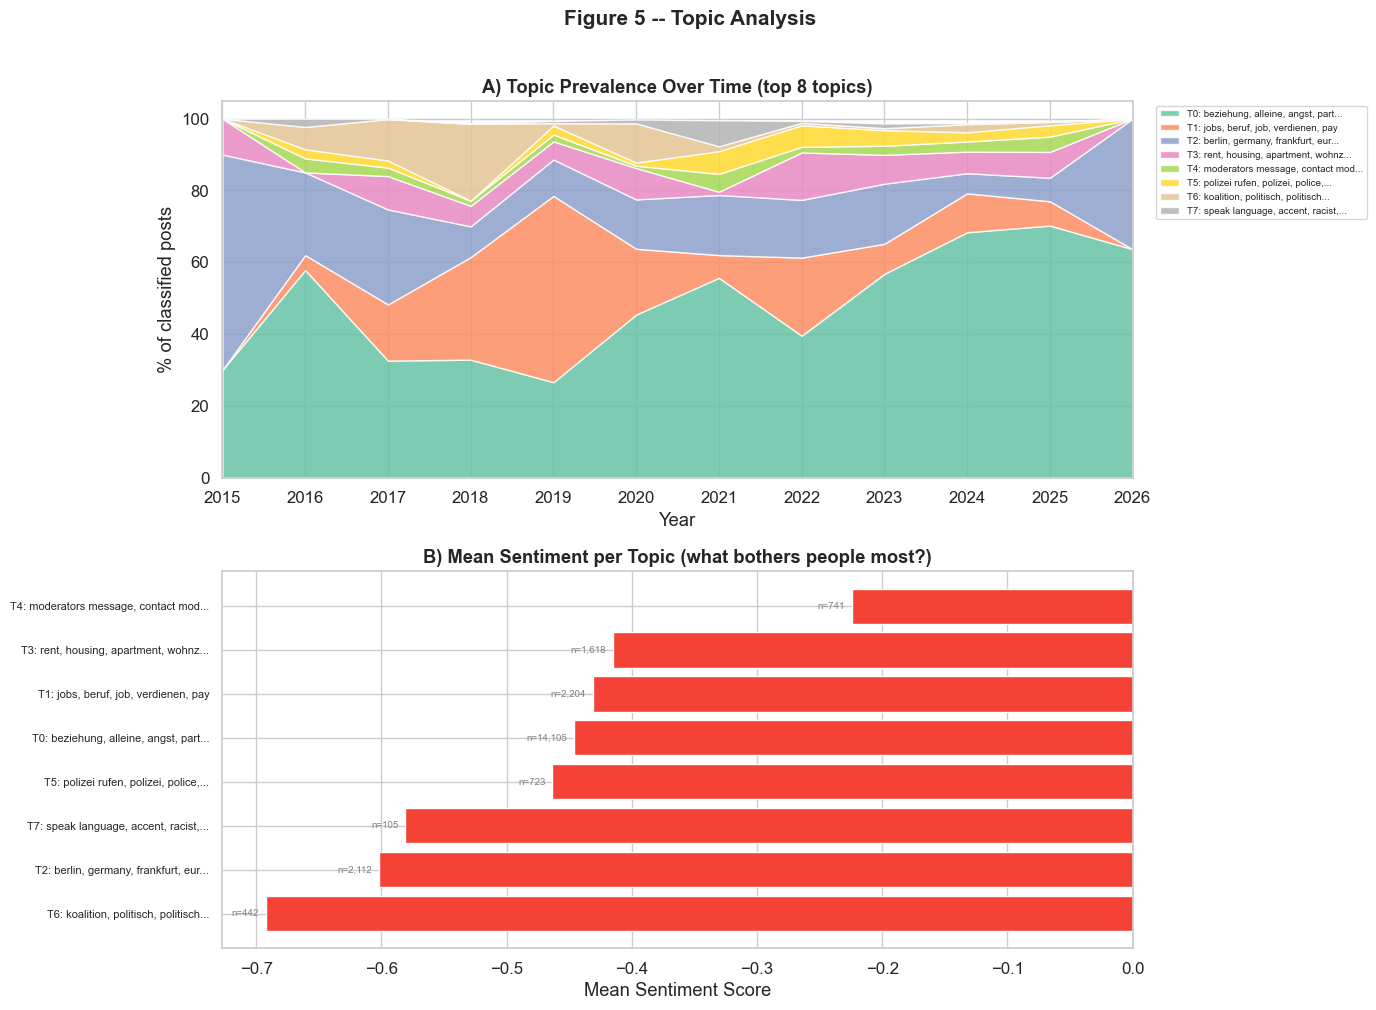

Saved figure5_topics.png


In [42]:
# Cell 8d — Figure 5: Topic evolution + topic sentiment

if len(df) > 0 and "topic_id" in df.columns:
    real = df[df["topic_id"] != -1].copy()
    top_tids = real["topic_id"].value_counts().head(8).index.tolist()

    # Build short labels
    short_labels = {}
    for tid in top_tids:
        lbl = real[real["topic_id"] == tid]["topic_label"].iloc[0]
        short_labels[tid] = lbl[:35] + "..." if len(lbl) > 37 else lbl

    years = sorted(real["year"].dropna().unique())
    prevalence = pd.DataFrame(index=years, columns=top_tids, dtype=float)
    for year in years:
        yr_df = real[real["year"] == year]
        yr_n = max(len(yr_df), 1)
        for tid in top_tids:
            prevalence.loc[year, tid] = (yr_df["topic_id"] == tid).sum() / yr_n * 100

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # ── A) Stacked area: topic prevalence over time ──
    ax = axes[0]
    colors = plt.cm.Set2(np.linspace(0, 1, len(top_tids)))
    ax.stackplot(
        years,
        [prevalence[tid].values for tid in top_tids],
        labels=[short_labels[t] for t in top_tids],
        colors=colors, alpha=0.85,
    )
    ax.set_title("A) Topic Prevalence Over Time (top 8 topics)", weight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("% of classified posts")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=7)
    ax.set_xticks(years)
    ax.set_xlim(min(years), max(years))

    # ── B) Horizontal bar: mean sentiment per topic ──
    ax = axes[1]
    topic_sent = real.groupby("topic_id")["sentiment_score"].mean().reindex(top_tids)
    topic_counts = real["topic_id"].value_counts().reindex(top_tids)

    bar_data = pd.DataFrame({
        "label": [short_labels[t] for t in top_tids],
        "mean_sent": topic_sent.values,
        "count": topic_counts.values,
    }).sort_values("mean_sent")

    bar_colors = [
        "#4CAF50" if v > 0.05 else "#F44336" if v < -0.05 else "#FFC107"
        for v in bar_data["mean_sent"]
    ]
    ax.barh(range(len(bar_data)), bar_data["mean_sent"],
            color=bar_colors, edgecolor="white")
    ax.set_yticks(range(len(bar_data)))
    ax.set_yticklabels(bar_data["label"], fontsize=8)
    ax.set_xlabel("Mean Sentiment Score")
    ax.set_title("B) Mean Sentiment per Topic (what bothers people most?)", weight="bold")
    ax.axvline(0, color="grey", linestyle=":", linewidth=0.8)
    for i, (_, row) in enumerate(bar_data.iterrows()):
        ax.annotate(
            f"n={int(row['count']):,}",
            xy=(row["mean_sent"], i),
            xytext=(5 if row["mean_sent"] >= 0 else -5, 0),
            textcoords="offset points",
            ha="left" if row["mean_sent"] >= 0 else "right",
            va="center", fontsize=7, color="grey",
        )

    plt.suptitle("Figure 5 -- Topic Analysis", fontsize=15, weight="bold", y=1.01)
    plt.tight_layout()
    fig.savefig("../figures/figure5_topics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved figure5_topics.png")
else:
    print("No topic data to plot.")

## Cell 8e — Figure 6: Era Comparison & Topic Deep-Dive

Comparing 2015-2020 vs 2021-2025: which topics grew, which shrank,
and how sentiment shifted within each topic between periods.

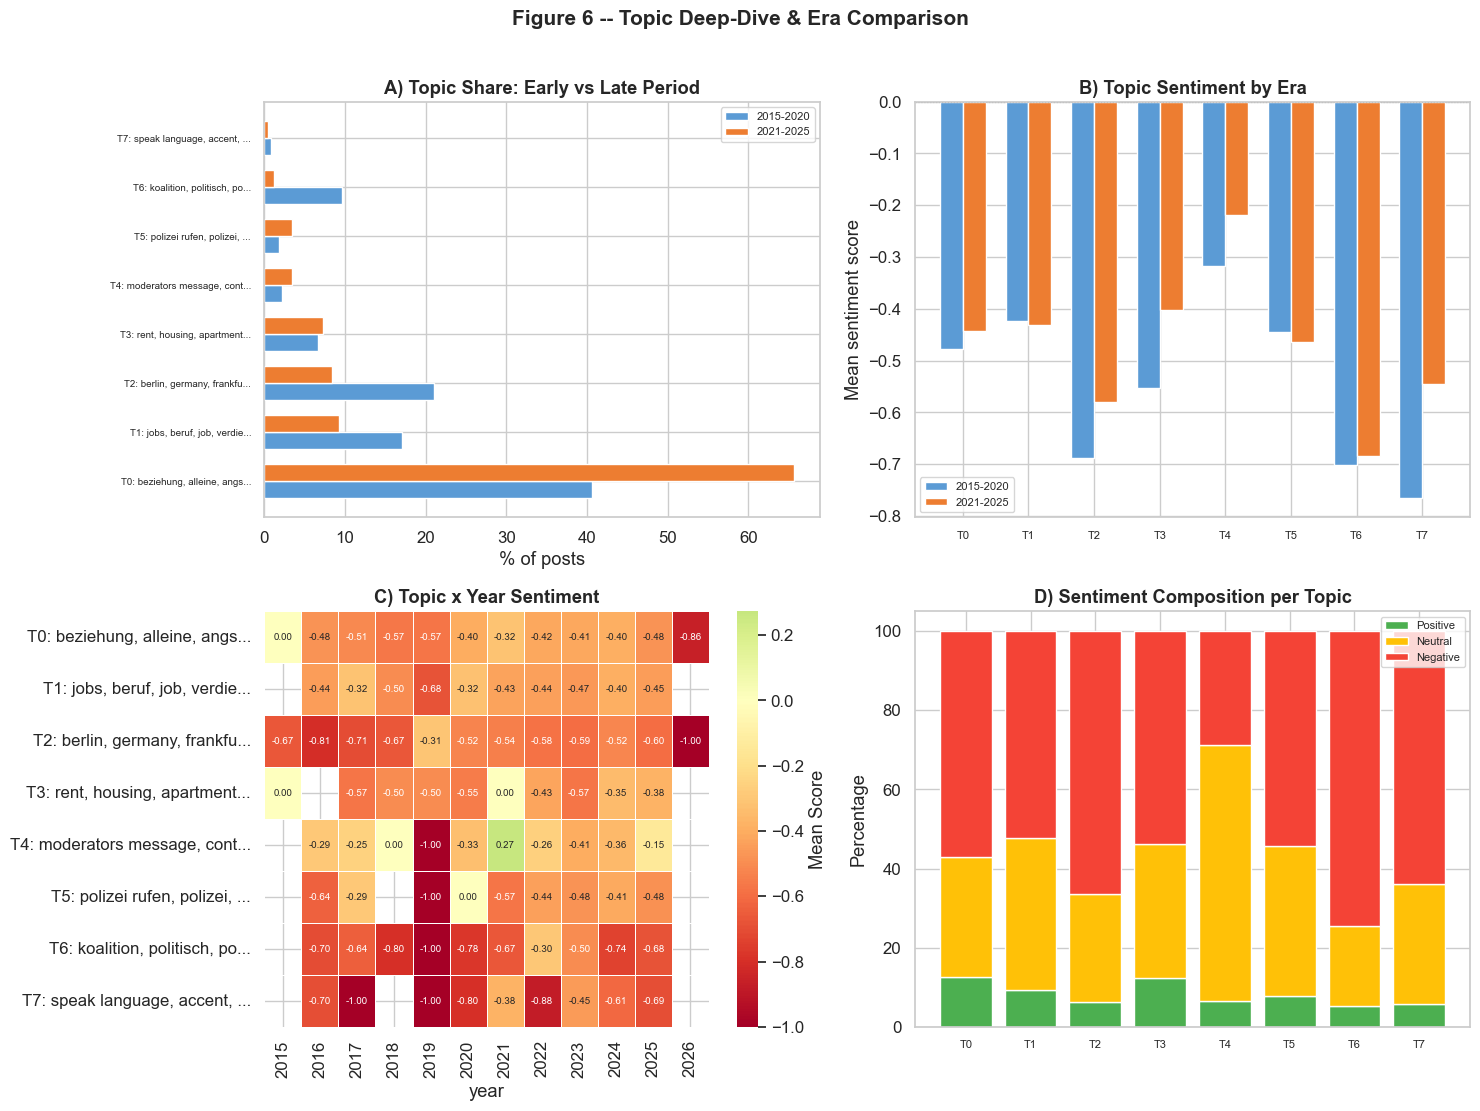

Saved figure6_topic_deepdive.png


In [43]:
# Cell 8e — Figure 6: Era comparison + topic deep-dive

if len(df) > 0 and "topic_id" in df.columns:
    real = df[df["topic_id"] != -1].copy()
    top_tids = real["topic_id"].value_counts().head(8).index.tolist()

    short_labels = {}
    for tid in top_tids:
        lbl = real[real["topic_id"] == tid]["topic_label"].iloc[0]
        short_labels[tid] = lbl[:28] + "..." if len(lbl) > 30 else lbl

    early = real[real["year"].between(2015, 2020)]
    late  = real[real["year"].between(2021, 2025)]

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    # ── A) Topic share: early vs late ──
    ax = axes[0, 0]
    if len(early) > 0 and len(late) > 0:
        early_pct = early["topic_id"].value_counts(normalize=True).reindex(top_tids, fill_value=0) * 100
        late_pct  = late["topic_id"].value_counts(normalize=True).reindex(top_tids, fill_value=0) * 100
        x = np.arange(len(top_tids))
        w = 0.35
        ax.barh(x - w/2, early_pct.values, w, label="2015-2020", color="#5B9BD5")
        ax.barh(x + w/2, late_pct.values, w, label="2021-2025", color="#ED7D31")
        ax.set_yticks(x)
        ax.set_yticklabels([short_labels[t] for t in top_tids], fontsize=7)
        ax.set_xlabel("% of posts")
        ax.legend(fontsize=8)
    ax.set_title("A) Topic Share: Early vs Late Period", weight="bold")

    # ── B) Topic sentiment by era ──
    ax = axes[0, 1]
    if len(early) > 0 and len(late) > 0:
        early_sent = early.groupby("topic_id")["sentiment_score"].mean().reindex(top_tids, fill_value=0)
        late_sent  = late.groupby("topic_id")["sentiment_score"].mean().reindex(top_tids, fill_value=0)
        x = np.arange(len(top_tids))
        w = 0.35
        ax.bar(x - w/2, early_sent.values, w, label="2015-2020", color="#5B9BD5")
        ax.bar(x + w/2, late_sent.values, w, label="2021-2025", color="#ED7D31")
        ax.set_xticks(x)
        ax.set_xticklabels([f"T{t}" for t in top_tids], fontsize=8)
        ax.set_ylabel("Mean sentiment score")
        ax.axhline(0, color="grey", linestyle=":", linewidth=0.8)
        ax.legend(fontsize=8)
    ax.set_title("B) Topic Sentiment by Era", weight="bold")

    # ── C) Heatmap: topic x year sentiment ──
    ax = axes[1, 0]
    heat = real.pivot_table(
        index="topic_id", columns="year",
        values="sentiment_score", aggfunc="mean"
    ).reindex(top_tids)
    heat.index = [short_labels[t] for t in top_tids]
    sns.heatmap(
        heat, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
        ax=ax, cbar_kws={"label": "Mean Score"}, linewidths=0.5,
        annot_kws={"fontsize": 7},
    )
    ax.set_title("C) Topic x Year Sentiment", weight="bold")
    ax.set_ylabel("")

    # ── D) Stacked sentiment per topic ──
    ax = axes[1, 1]
    tsd = []
    for tid in top_tids:
        sub = real[real["topic_id"] == tid]
        n_sub = max(len(sub), 1)
        tsd.append({
            "tid": tid,
            "pos": (sub["primary_sentiment"] == "positive").sum() / n_sub * 100,
            "neu": (sub["primary_sentiment"] == "neutral").sum() / n_sub * 100,
            "neg": (sub["primary_sentiment"] == "negative").sum() / n_sub * 100,
        })
    tsd = pd.DataFrame(tsd)
    x = np.arange(len(top_tids))
    ax.bar(x, tsd["pos"], label="Positive", color="#4CAF50", edgecolor="white")
    ax.bar(x, tsd["neu"], bottom=tsd["pos"], label="Neutral", color="#FFC107", edgecolor="white")
    ax.bar(x, tsd["neg"], bottom=tsd["pos"] + tsd["neu"],
           label="Negative", color="#F44336", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([f"T{t}" for t in top_tids], fontsize=8)
    ax.set_ylabel("Percentage")
    ax.set_title("D) Sentiment Composition per Topic", weight="bold")
    ax.legend(fontsize=8)

    plt.suptitle("Figure 6 -- Topic Deep-Dive & Era Comparison",
                 fontsize=15, weight="bold", y=1.01)
    plt.tight_layout()
    fig.savefig("../figures/figure6_topic_deepdive.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved figure6_topic_deepdive.png")
else:
    print("No topic data to plot.")

## Cell 9 — Statistical Tests

Five non-parametric and correlation tests to assess whether sentiment  
has changed significantly over time and across communities.

In [44]:
# Cell 9 — Statistical tests with plain-English interpretation

stat_results = {}

if len(df) > 0 and "sentiment_score" in df.columns:
    yearly_mean = df.groupby("year")["sentiment_score"].mean()
    years_sorted = sorted(yearly_mean.index)
    means_sorted = [yearly_mean[y] for y in years_sorted]

    print("=" * 72)
    print("STATISTICAL ANALYSIS")
    print("=" * 72)

    # 1. Mann-Kendall (Kendall's tau) trend test
    tau, p_mk = stats.kendalltau(range(len(means_sorted)), means_sorted)
    direction = "positive" if tau > 0 else "negative" if tau < 0 else "no"
    sig = "Significant" if p_mk < 0.05 else "Not significant"
    stat_results["mann_kendall"] = {"tau": round(tau, 4), "p_value": round(p_mk, 4)}
    print(f"\n1. Mann-Kendall Trend Test (Kendall τ)")
    print(f"   τ = {tau:.4f},  p = {p_mk:.4f}")
    print(f"   → {sig} {direction} trend in yearly mean sentiment.")

    # 2. Kruskal-Wallis across all years
    year_groups = [g["sentiment_score"].values for _, g in df.groupby("year") if len(g) > 0]
    if len(year_groups) >= 2:
        h_stat, p_kw = stats.kruskal(*year_groups)
    else:
        h_stat, p_kw = 0, 1.0
    sig = "Significant" if p_kw < 0.05 else "Not significant"
    stat_results["kruskal_wallis"] = {"H": round(h_stat, 4), "p_value": round(p_kw, 4)}
    print(f"\n2. Kruskal-Wallis Test (across all years)")
    print(f"   H = {h_stat:.4f},  p = {p_kw:.4f}")
    print(f"   → {sig} difference in sentiment distributions across years.")

    # 3. Mann-Whitney U: 2015-2020 vs 2021-2025
    early = df[df["year"].between(2015, 2020)]["sentiment_score"]
    late = df[df["year"].between(2021, 2025)]["sentiment_score"]
    if len(early) > 0 and len(late) > 0:
        u_stat, p_mw = stats.mannwhitneyu(early, late, alternative="two-sided")
    else:
        u_stat, p_mw = 0, 1.0
    sig = "Significant" if p_mw < 0.05 else "Not significant"
    stat_results["mann_whitney"] = {"U": round(u_stat, 4), "p_value": round(p_mw, 4)}
    diff_dir = "more positive" if late.mean() > early.mean() else "more negative"
    print(f"\n3. Mann-Whitney U Test (2015–2020 vs 2021–2025)")
    print(f"   U = {u_stat:.4f},  p = {p_mw:.4f}")
    print(f"   → {sig} shift; the later period is {diff_dir} on average.")

    # 4. Chi-square: sentiment distribution × subreddit
    ct = pd.crosstab(df["subreddit"], df["primary_sentiment"])
    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
        chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
    else:
        chi2, p_chi, dof = 0, 1.0, 0
    sig = "Significant" if p_chi < 0.05 else "Not significant"
    stat_results["chi_square"] = {"chi2": round(chi2, 4), "p_value": round(p_chi, 4), "dof": dof}
    print(f"\n4. Chi-Square Test (sentiment × subreddit)")
    print(f"   χ² = {chi2:.4f},  p = {p_chi:.4f},  dof = {dof}")
    print(f"   → {sig} association between subreddit and sentiment distribution.")

    # 5. Pearson correlation: post volume vs % negative per year
    yr_vol = df.groupby("year").size()
    yr_neg = df.groupby("year").apply(lambda x: (x["primary_sentiment"] == "negative").mean())
    common_yrs = sorted(set(yr_vol.index) & set(yr_neg.index))
    if len(common_yrs) >= 3:
        r_val, p_corr = stats.pearsonr(
            [yr_vol[y] for y in common_yrs],
            [yr_neg[y] for y in common_yrs]
        )
    else:
        r_val, p_corr = 0, 1.0
    sig = "Significant" if p_corr < 0.05 else "Not significant"
    stat_results["pearson_vol_neg"] = {"r": round(r_val, 4), "p_value": round(p_corr, 4)}
    direction = "positive" if r_val > 0 else "negative"
    print(f"\n5. Pearson Correlation (post volume vs % negative)")
    print(f"   r = {r_val:.4f},  p = {p_corr:.4f}")
    print(f"   → {sig} {direction} correlation between post volume and negativity.")

    print("\n" + "=" * 72)
else:
    print("⚠️  Insufficient data for statistical tests.")

STATISTICAL ANALYSIS

1. Mann-Kendall Trend Test (Kendall τ)
   τ = 0.0909,  p = 0.7373
   → Not significant positive trend in yearly mean sentiment.

2. Kruskal-Wallis Test (across all years)
   H = 140.6558,  p = 0.0000
   → Significant difference in sentiment distributions across years.

3. Mann-Whitney U Test (2015–2020 vs 2021–2025)
   U = 93104422.0000,  p = 0.0000
   → Significant shift; the later period is more positive on average.

4. Chi-Square Test (sentiment × subreddit)
   χ² = 739.8902,  p = 0.0000,  dof = 38
   → Significant association between subreddit and sentiment distribution.

5. Pearson Correlation (post volume vs % negative)
   r = -0.1849,  p = 0.5652
   → Not significant negative correlation between post volume and negativity.



## Cell 10 — Figure 1: Post Volume per Year by Subreddit

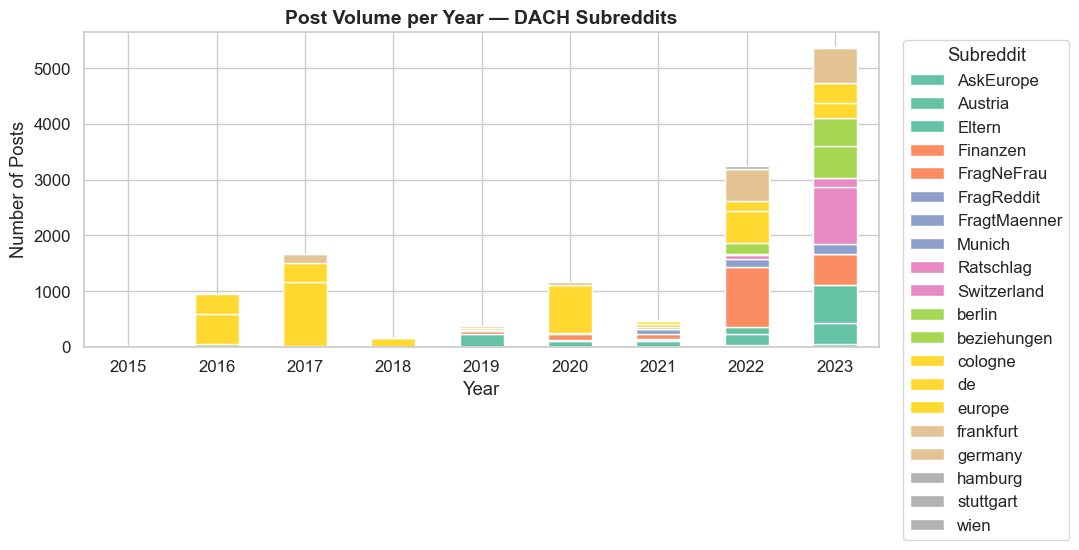

💾 Saved figure1_volume.png


In [45]:
# Cell 10 — Figure 1: Stacked bar chart of post volume

if len(df) > 0:
    pivot = df.pivot_table(index="year", columns="subreddit",
                           values="id", aggfunc="count", fill_value=0)
    pivot = pivot.reindex(YEARS, fill_value=0)

    fig, ax = plt.subplots(figsize=(11, 5))
    pivot.plot(kind="bar", stacked=True, ax=ax, colormap="Set2", edgecolor="white")
    ax.set_title("Post Volume per Year — DACH Subreddits", fontsize=14, weight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of Posts")
    ax.set_xticklabels([str(y) for y in YEARS], rotation=0)
    ax.legend(title="Subreddit", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    fig.savefig("../figures/figure1_volume.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved figure1_volume.png")
else:
    print("⚠️  No data to plot.")

## Cell 11 — Figure 2: Four-Panel Sentiment Overview

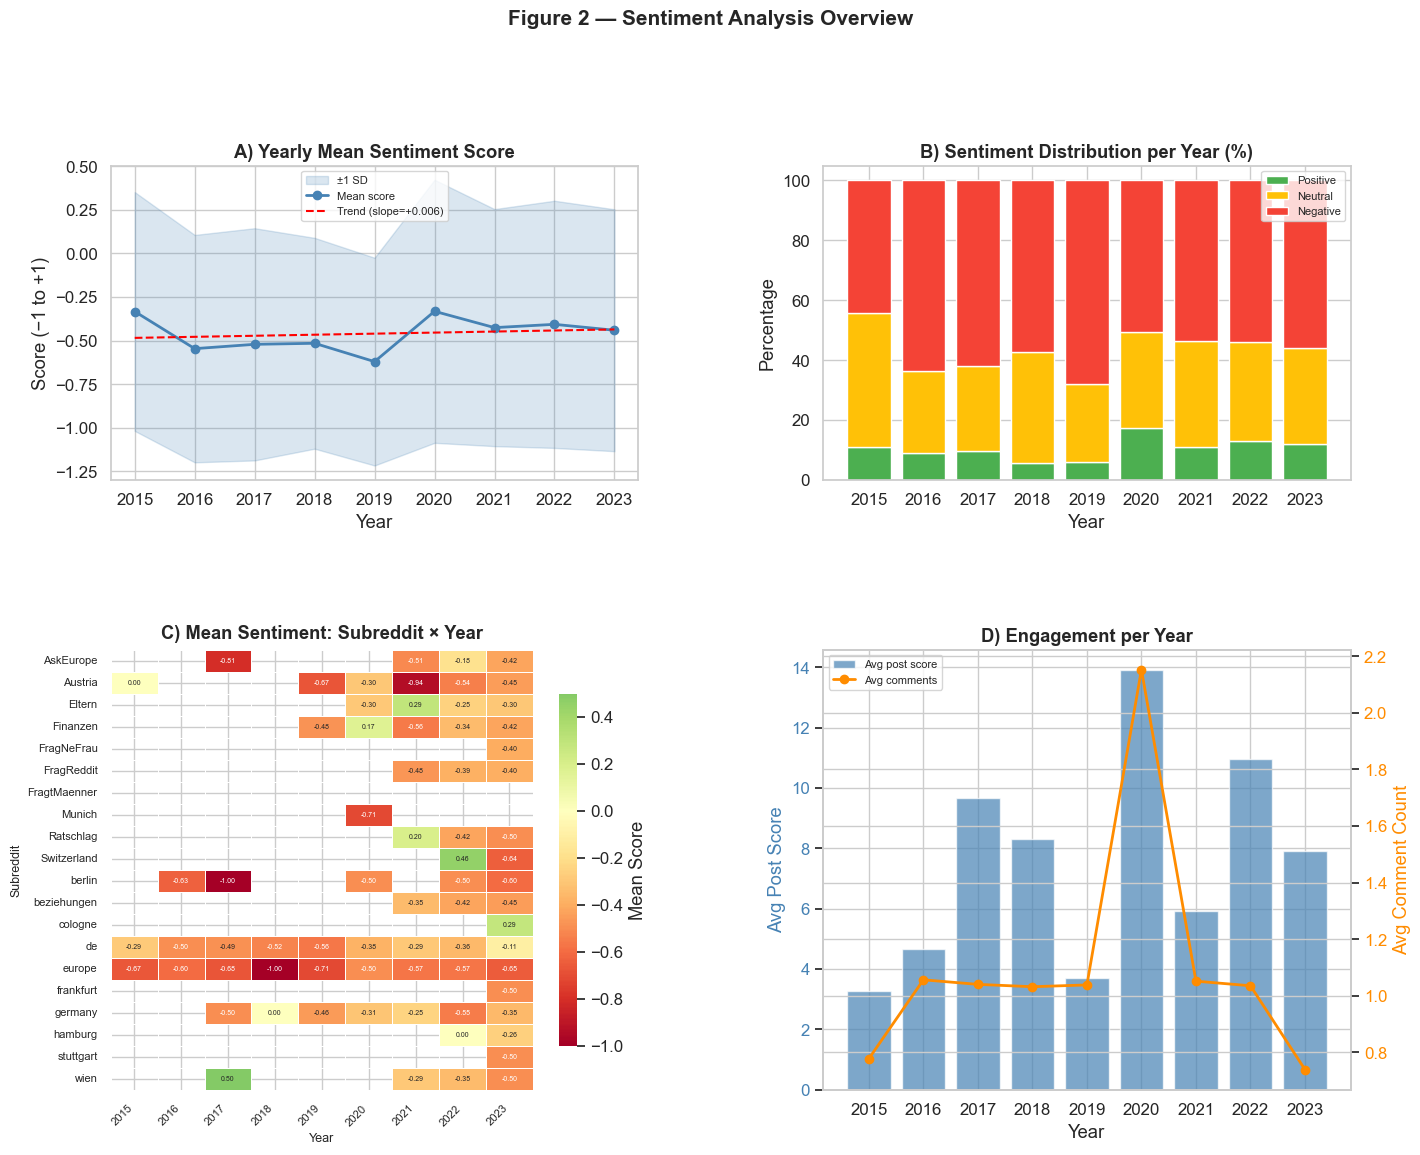

💾 Saved figure2_sentiment.png


In [50]:
# Cell 11 — Figure 2: Four-panel sentiment overview

if len(df) > 0 and "sentiment_score" in df.columns:
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.4], hspace=0.45, wspace=0.35)
    axes = [[fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
            [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]]

    # ── A) Mean sentiment per year with trend line and SD band ──
    ax = axes[0][0]
    ym = df.groupby("year")["sentiment_score"].agg(["mean", "std"]).reindex(YEARS)
    ax.fill_between(ym.index, ym["mean"] - ym["std"], ym["mean"] + ym["std"],
                    alpha=0.2, color="steelblue", label="±1 SD")
    ax.plot(ym.index, ym["mean"], "o-", color="steelblue", linewidth=2, label="Mean score")
    valid = ym["mean"].dropna()
    if len(valid) >= 2:
        z = np.polyfit(valid.index, valid.values, 1)
        ax.plot(valid.index, np.polyval(z, valid.index), "--", color="red",
                linewidth=1.5, label=f"Trend (slope={z[0]:+.3f})")
    ax.set_title("A) Yearly Mean Sentiment Score", weight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Score (−1 to +1)")
    ax.legend(fontsize=8); ax.set_xticks(YEARS)

    # ── B) Stacked % bar chart ──
    ax = axes[0][1]
    yr_sent = df.groupby(["year", "primary_sentiment"]).size().unstack(fill_value=0)
    yr_pct = yr_sent.div(yr_sent.sum(axis=1), axis=0) * 100
    yr_pct = yr_pct.reindex(YEARS, fill_value=0)
    colors = {"positive": "#4CAF50", "neutral": "#FFC107", "negative": "#F44336"}
    bottom = np.zeros(len(YEARS))
    for label in ["positive", "neutral", "negative"]:
        vals = yr_pct[label].values if label in yr_pct.columns else np.zeros(len(YEARS))
        ax.bar(YEARS, vals, bottom=bottom, label=label.capitalize(),
               color=colors[label], edgecolor="white")
        bottom += vals
    ax.set_title("B) Sentiment Distribution per Year (%)", weight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Percentage")
    ax.legend(fontsize=8); ax.set_xticks(YEARS)

    # ── C) Heatmap: subreddit × year ──
    ax = axes[1][0]
    heat = df.pivot_table(index="subreddit", columns="year",
                          values="sentiment_score", aggfunc="mean")
    heat = heat.reindex(columns=YEARS)

    n_rows = heat.shape[0]
    annot_fs = max(5, min(8, int(60 / max(n_rows, len(YEARS)))))

    sns.heatmap(
        heat, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
        ax=ax, cbar_kws={"label": "Mean Score", "shrink": 0.8},
        linewidths=0.4, linecolor="white",
        annot_kws={"fontsize": annot_fs},
    )
    ax.set_title("C) Mean Sentiment: Subreddit × Year", weight="bold", pad=8)
    ax.set_xlabel("Year", fontsize=9)
    ax.set_ylabel("Subreddit", fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

    # ── D) Dual-axis: avg score (bars) + avg comments (line) ──
    ax = axes[1][1]
    yr_stats = df.groupby("year").agg(
        avg_score=("score", "mean"),
        avg_comments=("num_comments", "mean")
    ).reindex(YEARS)
    ax.bar(YEARS, yr_stats["avg_score"], color="steelblue", alpha=0.7, label="Avg post score")
    ax.set_xlabel("Year"); ax.set_ylabel("Avg Post Score", color="steelblue")
    ax.tick_params(axis="y", labelcolor="steelblue")
    ax.set_xticks(YEARS)

    ax2 = ax.twinx()
    ax2.plot(YEARS, yr_stats["avg_comments"], "o-", color="darkorange",
             linewidth=2, label="Avg comments")
    ax2.set_ylabel("Avg Comment Count", color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")
    ax.set_title("D) Engagement per Year", weight="bold")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")

    plt.suptitle("Figure 2 — Sentiment Analysis Overview", fontsize=15, weight="bold", y=1.01)
    fig.savefig("../figures/figure2_sentiment.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved figure2_sentiment.png")
else:
    print("⚠️  No sentiment data to plot.")

## Cell 12 — Figure 3: Language & Keyword Trends

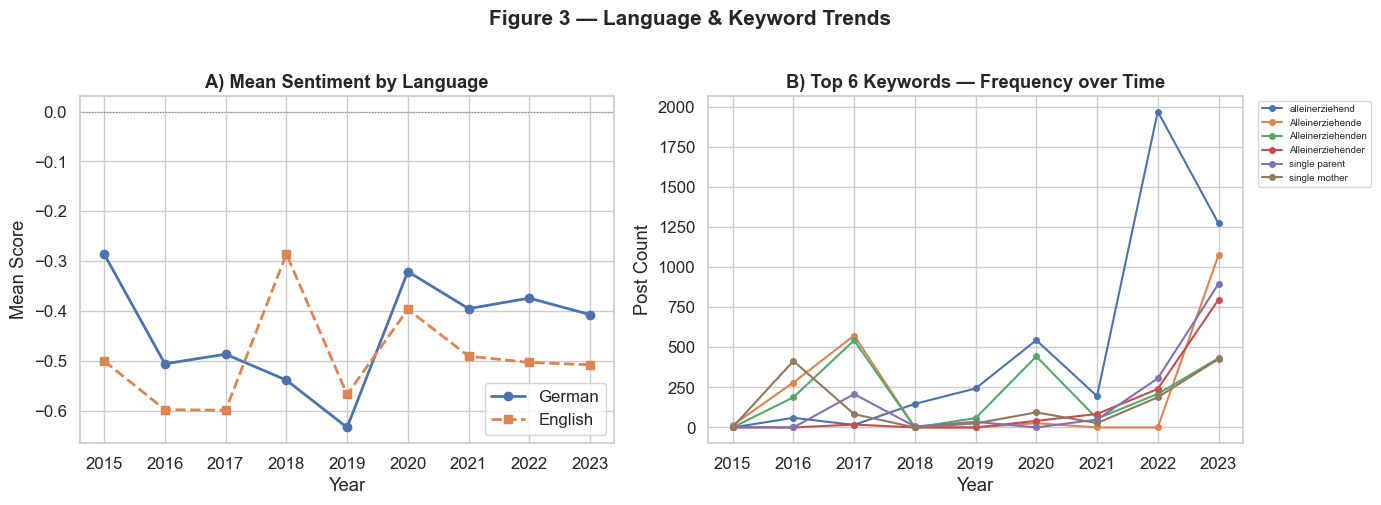

💾 Saved figure3_language_keywords.png


In [47]:
# Cell 12 — Figure 3: Language split + keyword frequency over time

if len(df) > 0 and "sentiment_score" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── A) Sentiment by language per year ──
    ax = axes[0]
    for lang, style in [("de", "o-"), ("en", "s--")]:
        sub = df[df["language"] == lang]
        ym = sub.groupby("year")["sentiment_score"].mean().reindex(YEARS)
        label = "German" if lang == "de" else "English"
        ax.plot(ym.index, ym.values, style, label=label, linewidth=2, markersize=6)
    ax.axhline(0, color="grey", linestyle=":", linewidth=0.8)
    ax.set_title("A) Mean Sentiment by Language", weight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Mean Score")
    ax.legend(); ax.set_xticks(YEARS)

    # ── B) Top 6 keywords frequency over time ──
    ax = axes[1]
    kw_yr = df.groupby(["_query_keyword", "year"]).size().unstack(fill_value=0)
    top6 = kw_yr.sum(axis=1).nlargest(6).index
    for kw in top6:
        vals = kw_yr.loc[kw].reindex(YEARS, fill_value=0)
        ax.plot(vals.index, vals.values, "o-", label=kw[:25], linewidth=1.5, markersize=4)
    ax.set_title("B) Top 6 Keywords — Frequency over Time", weight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Post Count")
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_xticks(YEARS)

    plt.suptitle("Figure 3 — Language & Keyword Trends", fontsize=15, weight="bold", y=1.01)
    plt.tight_layout()
    fig.savefig("../figures/figure3_language_keywords.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved figure3_language_keywords.png")
else:
    print("⚠️  No data to plot.")

## Cell 13 — Figure 4: Opinion Distribution Summary

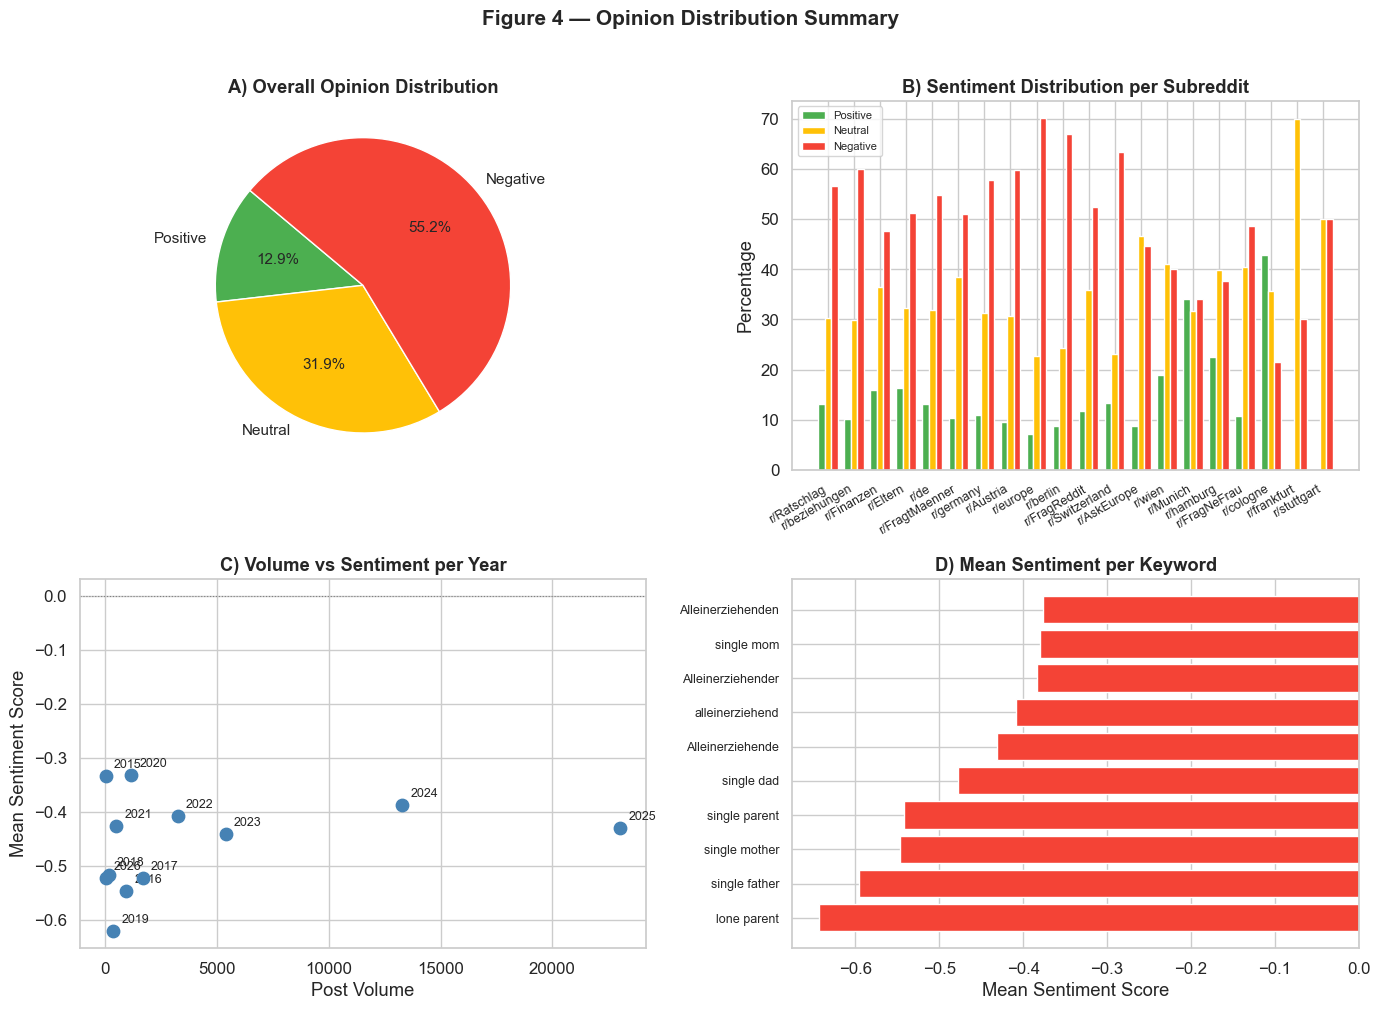

💾 Saved figure4_opinion.png


In [48]:
# Cell 13 — Figure 4: Four-panel opinion distribution summary

if len(df) > 0 and "primary_sentiment" in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors_list = ["#4CAF50", "#FFC107", "#F44336"]
    labels_order = ["positive", "neutral", "negative"]

    # ── A) Pie chart: overall split ──
    ax = axes[0, 0]
    counts = [int((df["primary_sentiment"] == l).sum()) for l in labels_order]
    ax.pie(counts, labels=[l.capitalize() for l in labels_order],
           colors=colors_list, autopct="%1.1f%%", startangle=140,
           textprops={"fontsize": 11})
    ax.set_title("A) Overall Opinion Distribution", weight="bold")

    # ── B) Grouped bar: sentiment per subreddit ──
    ax = axes[0, 1]
    subs = df["subreddit"].value_counts().index.tolist()
    x = np.arange(len(subs))
    width = 0.25
    for i, label in enumerate(labels_order):
        vals = [(df[(df["subreddit"] == s) & (df["primary_sentiment"] == label)].shape[0]
                 / max(df[df["subreddit"] == s].shape[0], 1)) * 100 for s in subs]
        ax.bar(x + i * width, vals, width, label=label.capitalize(), color=colors_list[i])
    ax.set_xticks(x + width)
    ax.set_xticklabels([f"r/{s}" for s in subs], rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Percentage")
    ax.set_title("B) Sentiment Distribution per Subreddit", weight="bold")
    ax.legend(fontsize=8)

    # ── C) Scatter: post volume vs mean sentiment per year ──
    ax = axes[1, 0]
    yr_agg = df.groupby("year").agg(
        volume=("id", "count"),
        mean_sent=("sentiment_score", "mean")
    )
    ax.scatter(yr_agg["volume"], yr_agg["mean_sent"], s=80, c="steelblue", zorder=5)
    for yr, row in yr_agg.iterrows():
        ax.annotate(str(int(yr)), (row["volume"], row["mean_sent"]),
                    textcoords="offset points", xytext=(6, 6), fontsize=9)
    ax.set_xlabel("Post Volume")
    ax.set_ylabel("Mean Sentiment Score")
    ax.set_title("C) Volume vs Sentiment per Year", weight="bold")
    ax.axhline(0, color="grey", linestyle=":", linewidth=0.8)

    # ── D) Bar: mean sentiment per keyword ──
    ax = axes[1, 1]
    kw_sent = df.groupby("_query_keyword")["sentiment_score"].mean().sort_values(ascending=False)
    bar_colors = ["#4CAF50" if v > 0.05 else "#F44336" if v < -0.05 else "#FFC107"
                  for v in kw_sent.values]
    ax.barh(range(len(kw_sent)), kw_sent.values, color=bar_colors)
    ax.set_yticks(range(len(kw_sent)))
    ax.set_yticklabels(kw_sent.index, fontsize=9)
    ax.set_xlabel("Mean Sentiment Score")
    ax.set_title("D) Mean Sentiment per Keyword", weight="bold")
    ax.axvline(0, color="grey", linestyle=":", linewidth=0.8)
    ax.invert_yaxis()

    plt.suptitle("Figure 4 — Opinion Distribution Summary",
                 fontsize=15, weight="bold", y=1.01)
    plt.tight_layout()
    fig.savefig("../figures/figure4_opinion.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved figure4_opinion.png")
else:
    print("⚠️  No data to plot.")

## Cell 14 — Export All Outputs

Save the full annotated dataset, yearly aggregates, and analysis metadata.

In [49]:
# Cell 14 — Export CSV, JSON, and summary files

if len(df) > 0:
    # ── Full dataset CSV ──
    export_cols = [
        "id", "type", "parent_post_id", "subreddit", "author", "title",
        "full_text", "score", "num_comments", "created_utc", "date", "year",
        "language", "_query_keyword", "vader_sentiment", "roberta_sentiment",
        "roberta_confidence", "primary_sentiment", "sentiment_score",
        "topic_id", "topic_label",
    ]
    existing_cols = [c for c in export_cols if c in df.columns]
    df[existing_cols].to_csv("../data/reddit/reddit_dach_singleparent_full.csv", index=False)
    print("💾 reddit_dach_singleparent_full.csv")

    # ── Comments-only CSV ──
    comments_df = df[df["type"] == "comment"]
    comments_df[existing_cols].to_csv("../data/reddit/reddit_dach_singleparent_comments.csv", index=False)
    print(f"💾 reddit_dach_singleparent_comments.csv  ({len(comments_df):,} comments)")

    # ── Yearly aggregates CSV ──
    yearly_agg = df.groupby("year").agg(
        total_posts=("id", "count"),
        mean_score=("score", "mean"),
        mean_comments=("num_comments", "mean"),
        mean_sentiment=("sentiment_score", "mean"),
        pct_positive=("primary_sentiment", lambda x: (x == "positive").mean() * 100),
        pct_neutral=("primary_sentiment", lambda x: (x == "neutral").mean() * 100),
        pct_negative=("primary_sentiment", lambda x: (x == "negative").mean() * 100),
        pct_german=("language", lambda x: (x == "de").mean() * 100),
    ).round(3)
    yearly_agg.to_csv("../data/reddit/yearly_aggregates.csv")
    print("💾 yearly_aggregates.csv")

    # ── Analysis summary JSON ──
    summary = {
        "metadata": {
            "generated": datetime.now().isoformat(),
            "subreddits": SUBREDDITS,
            "keywords": KEYWORDS,
            "year_range": [YEAR_START, YEAR_END],
            "total_records": len(df),
            "total_posts": int((df["type"] == "post").sum()),
            "total_comments": int((df["type"] == "comment").sum()),
        },
        "preprocessing": PREPROCESS_STATS,
        "statistical_tests": stat_results if "stat_results" in dir() else {},
        "overall_sentiment": {
            "positive": int((df["primary_sentiment"] == "positive").sum()),
            "neutral": int((df["primary_sentiment"] == "neutral").sum()),
            "negative": int((df["primary_sentiment"] == "negative").sum()),
            "mean_score": round(df["sentiment_score"].mean(), 4),
        },
    }
    if "topic_id" in df.columns:
        summary["topics"] = {
            "n_topics": int(df[df["topic_id"] != -1]["topic_id"].nunique()),
            "n_outliers": int((df["topic_id"] == -1).sum()),
            "topic_distribution": {
                str(k): int(v) for k, v in df["topic_id"].value_counts().to_dict().items()
            },
        }

    with open("../reports/analysis_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2, ensure_ascii=False, default=str)
    print("💾 analysis_summary.json")

    # Confirm text reports exist
    for fname in ["../reports/dataset_report.txt", "../reports/opinion_summary.txt", "../reports/topic_report.txt"]:
        status = "✅" if os.path.exists(fname) else "⚠️  missing"
        print(f"{status} {fname}")

    # List all figure files
    for fname in ["../figures/figure1_volume.png", "../figures/figure2_sentiment.png",
                  "../figures/figure3_language_keywords.png", "../figures/figure4_opinion.png",
                  "../figures/figure5_topics.png", "../figures/figure6_topic_deepdive.png"]:
        status = "✅" if os.path.exists(fname) else "⚠️  missing"
        print(f"{status} {fname}")

    print("\n🎉 All outputs exported. Analysis complete!")
else:
    print("⚠️  No data to export.")

💾 reddit_dach_singleparent_full.csv
💾 reddit_dach_singleparent_comments.csv  (48,638 comments)
💾 yearly_aggregates.csv
💾 analysis_summary.json
✅ dataset_report.txt
✅ opinion_summary.txt
✅ topic_report.txt
✅ figure1_volume.png
✅ figure2_sentiment.png
✅ figure3_language_keywords.png
✅ figure4_opinion.png
✅ figure5_topics.png
✅ figure6_topic_deepdive.png

🎉 All outputs exported. Analysis complete!
